# Domain-Clustered Vocabulary for GliZNet Data Generation

## The Problem

GliZNet's training data (ZSHOT-HARDSET-v2, 1.65M rows) suffers from **extreme label sparsity**:
- **1.53M distinct positive labels** across 1.65M rows → most labels appear exactly once
- **50.6%** of labels are singletons (appear only 1 time)
- **90.7%** of labels appear ≤5 times
- The model never sees the same label twice → can't learn reusable label representations

**Root cause**: The LLM invents all 15 labels from scratch for each Wikipedia excerpt bundle. With ~330K bundles, this produces ~330K × 15 = ~5M label-uses spread across ~1.5M unique labels.

## The Solution: Domain-Clustered Vocabulary

Instead of letting the LLM invent labels, we provide a **fixed vocabulary** organized into **~100 semantic clusters**. For each Wikipedia excerpt:

1. **Select 2-4 relevant clusters** based on the excerpt's content domain
2. **Sample ~100-150 candidate labels** from those clusters
3. **Pass candidates to the LLM** — it SELECTS 15 labels instead of inventing them

**Why this preserves hard negatives**: Labels within the same cluster are semantically related (e.g., "root_cause" vs "contributing_factor" in the causal_mechanism cluster). The LLM still decides which labels are true/false for each text, but now the negatives come from the same semantic neighborhood — they're genuinely confusable.

In [4]:
import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# Load the taxonomy
taxonomy_path = Path("../data/pretrain/label_taxonomy.json")
with open(taxonomy_path) as f:
    taxonomy_data = json.load(f)

clusters = taxonomy_data["clusters"]
metadata = taxonomy_data["metadata"]

print(f"Taxonomy version: {metadata['version']}")
print(f"Total clusters: {len(clusters)}")
print(f"Total unique labels: {len(set(l for c in clusters.values() for l in c['labels']))}")
print(f"Total label slots: {sum(len(c['labels']) for c in clusters.values())}")
print(f"\nCategories: {sorted(set(c['category'] for c in clusters.values()))}")
print(f"\n{metadata['description']}")

Taxonomy version: 1.0
Total clusters: 99
Total unique labels: 1952
Total label slots: 2000

Categories: ['arts', 'causal', 'conflict', 'culture', 'economics', 'education', 'emotional', 'environment', 'epistemic', 'ethics', 'health', 'history', 'information', 'language', 'legal', 'nature', 'philosophy', 'politics', 'process', 'rhetorical', 'science', 'scope', 'social', 'society', 'spatial', 'technology', 'temporal']

Domain-clustered label taxonomy for GliZNet data generation. Labels within each cluster are semantically related (hard negatives for each other). All labels are 1-2 words in snake_case.


## Taxonomy Overview

The taxonomy organizes labels into **semantic clusters** grouped by **category**. Each cluster contains 20-30 labels that are semantically related — close enough to be confusable (hard negatives for each other), but distinct enough to carry different meanings.

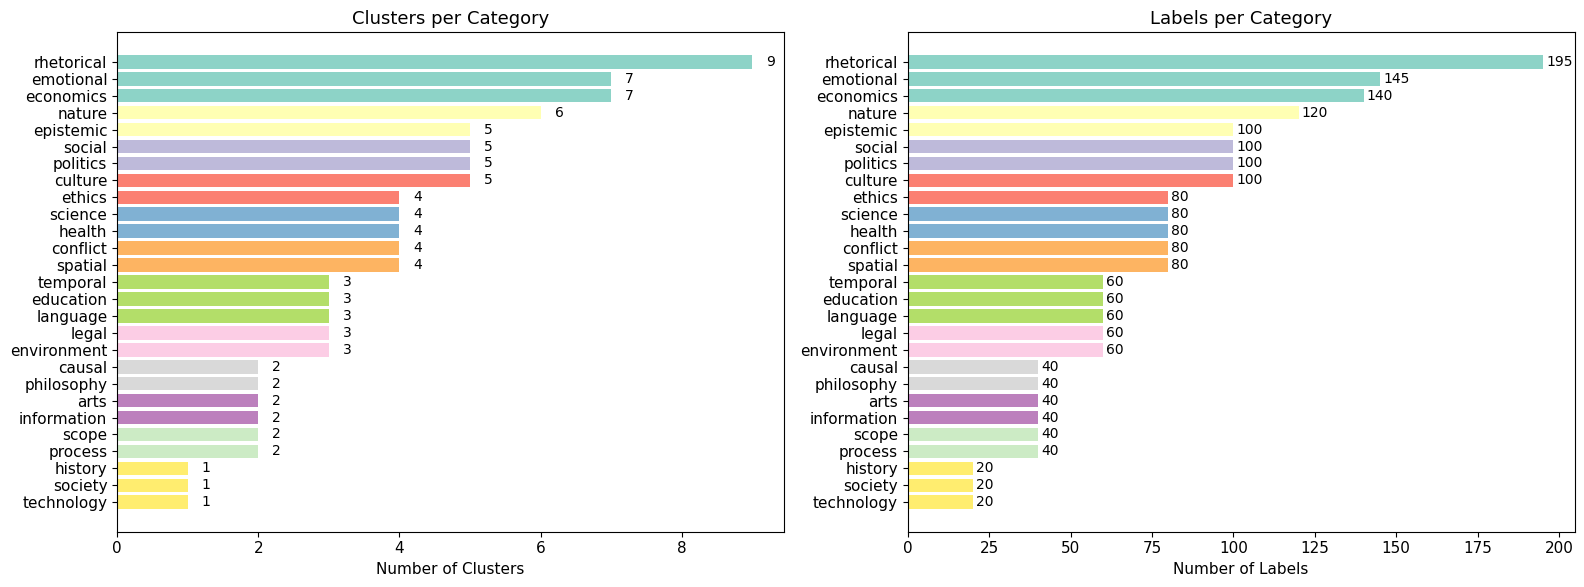


Category             Clusters   Labels  Avg/Cluster
rhetorical                  9      195         21.7
emotional                   7      145         20.7
economics                   7      140         20.0
nature                      6      120         20.0
epistemic                   5      100         20.0
social                      5      100         20.0
politics                    5      100         20.0
culture                     5      100         20.0
ethics                      4       80         20.0
science                     4       80         20.0
health                      4       80         20.0
conflict                    4       80         20.0
spatial                     4       80         20.0
temporal                    3       60         20.0
education                   3       60         20.0
language                    3       60         20.0
legal                       3       60         20.0
environment                 3       60         20.0
causal     

In [2]:
# Category breakdown
cat_counts = Counter(c["category"] for c in clusters.values())
cat_labels_counts = {}
for cname, cdata in clusters.items():
    cat = cdata["category"]
    cat_labels_counts[cat] = cat_labels_counts.get(cat, 0) + len(cdata["labels"])

# Sort by cluster count
cats_sorted = sorted(cat_counts.keys(), key=lambda x: cat_counts[x], reverse=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Clusters per category
colors = plt.cm.Set3(np.linspace(0, 1, len(cats_sorted)))
bars1 = ax1.barh(cats_sorted, [cat_counts[c] for c in cats_sorted], color=colors)
ax1.set_xlabel("Number of Clusters")
ax1.set_title("Clusters per Category")
ax1.invert_yaxis()
for bar, cat in zip(bars1, cats_sorted):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             str(cat_counts[cat]), va='center', fontsize=10)

# Labels per category
bars2 = ax2.barh(cats_sorted, [cat_labels_counts[c] for c in cats_sorted], color=colors)
ax2.set_xlabel("Number of Labels")
ax2.set_title("Labels per Category")
ax2.invert_yaxis()
for bar, cat in zip(bars2, cats_sorted):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(cat_labels_counts[cat]), va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Category':<20} {'Clusters':>8} {'Labels':>8} {'Avg/Cluster':>12}")
print("=" * 50)
for cat in cats_sorted:
    avg = cat_labels_counts[cat] / cat_counts[cat]
    print(f"{cat:<20} {cat_counts[cat]:>8} {cat_labels_counts[cat]:>8} {avg:>12.1f}")
print("=" * 50)
print(f"{'TOTAL':<20} {sum(cat_counts.values()):>8} {sum(cat_labels_counts.values()):>8} {sum(cat_labels_counts.values())/sum(cat_counts.values()):>12.1f}")

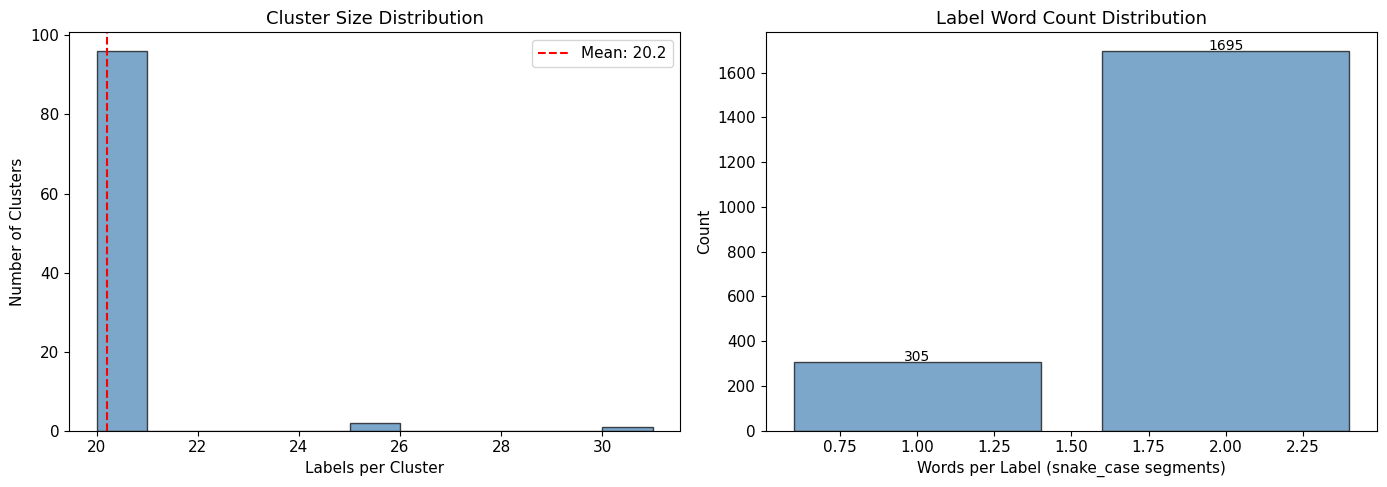


✅ All 2000 labels are 1-2 words (valid snake_case)

⚠️  48 labels appear in multiple clusters:
  - 'comparative_advantage' → ['persuasion_technique', 'trade_pattern']
  - 'qualification' → ['argumentative_move', 'discourse_pattern']
  - 'crisis_response' → ['framing_technique', 'mental_health']
  - 'individual_collective' → ['framing_technique', 'ethical_tension']
  - 'local_global' → ['framing_technique', 'ethical_tension']
  - 'freedom_security' → ['framing_technique', 'ethical_tension']
  - 'requesting' → ['communicative_intent', 'pragmatic_function']
  - 'apologizing' → ['communicative_intent', 'pragmatic_function']
  - 'questioning' → ['communicative_intent', 'pragmatic_function']
  - 'promising' → ['communicative_intent', 'pragmatic_function']


In [5]:
# Cluster size distribution
cluster_sizes = [len(c["labels"]) for c in clusters.values()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(cluster_sizes, bins=range(min(cluster_sizes), max(cluster_sizes)+2),
         edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel("Labels per Cluster")
ax1.set_ylabel("Number of Clusters")
ax1.set_title("Cluster Size Distribution")
ax1.axvline(np.mean(cluster_sizes), color='red', linestyle='--', label=f'Mean: {np.mean(cluster_sizes):.1f}')
ax1.legend()

# Label word count validation
all_labels = [l for c in clusters.values() for l in c["labels"]]
word_counts = [len(l.split("_")) for l in all_labels]
wc_counter = Counter(word_counts)

ax2.bar(wc_counter.keys(), wc_counter.values(), color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel("Words per Label (snake_case segments)")
ax2.set_ylabel("Count")
ax2.set_title("Label Word Count Distribution")
for x, y in wc_counter.items():
    ax2.text(x, y + 5, str(y), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Validate: all labels should be 1-2 words
invalid = [l for l in all_labels if len(l.split("_")) > 2]
if invalid:
    print(f"\n⚠️  {len(invalid)} labels with >2 words (need fixing):")
    for l in invalid[:20]:
        print(f"  - {l} ({len(l.split('_'))} words)")
else:
    print(f"\n✅ All {len(all_labels)} labels are 1-2 words (valid snake_case)")

# Check for duplicates across clusters
label_sources = {}
for cname, cdata in clusters.items():
    for l in cdata["labels"]:
        label_sources.setdefault(l, []).append(cname)
duplicates = {l: srcs for l, srcs in label_sources.items() if len(srcs) > 1}
if duplicates:
    print(f"\n⚠️  {len(duplicates)} labels appear in multiple clusters:")
    for l, srcs in list(duplicates.items())[:10]:
        print(f"  - '{l}' → {srcs}")
else:
    print(f"✅ No duplicate labels across clusters")

## Explore Clusters: Hard Negatives Within Clusters

The key insight: labels within the same cluster are **semantically related but distinct**. This makes them natural hard negatives — a naive classifier would confuse them, but a careful reader would distinguish them.

In [6]:
# Show a few representative clusters with their labels
showcase_clusters = [
    "causal_mechanism",
    "emotional_tone", 
    "certainty_level",
    "market_dynamic",
    "ecological_process",
    "conflict_dynamic",
]

for cname in showcase_clusters:
    cdata = clusters[cname]
    labels = cdata["labels"]
    print(f"━━━ {cname} ({cdata['category']}) — {len(labels)} labels ━━━")
    # Display in rows of 4
    for i in range(0, len(labels), 4):
        row = labels[i:i+4]
        print("  " + "  │  ".join(f"{l:<25}" for l in row))
    print()

print("💡 Notice how labels within each cluster are semantically close:")
print("   • 'root_cause' vs 'contributing_factor' vs 'proximate_trigger' — all about causation")
print("   • 'optimistic' vs 'hopeful' vs 'jubilant' — all positive emotions but different intensities")
print("   • 'established_fact' vs 'tentative_hypothesis' vs 'pure_speculation' — certainty gradient")

━━━ causal_mechanism (causal) — 20 labels ━━━
  direct_causation           │  indirect_influence         │  contributing_factor        │  root_cause               
  proximate_trigger          │  systemic_cause             │  structural_factor          │  catalytic_event          
  enabling_condition         │  necessary_condition        │  sufficient_condition       │  precipitating_factor     
  aggravating_circumstance   │  mitigating_factor          │  feedback_loop              │  chain_reaction           
  cumulative_effect          │  threshold_trigger          │  mediating_variable         │  confounding_factor       

━━━ emotional_tone (emotional) — 25 labels ━━━
  optimistic                 │  pessimistic                │  anxious                    │  hopeful                  
  resigned                   │  defiant                    │  melancholic                │  jubilant                 
  indignant                  │  compassionate              │  nostalgic         

## Full Taxonomy Map

Visual overview of all clusters organized by category.

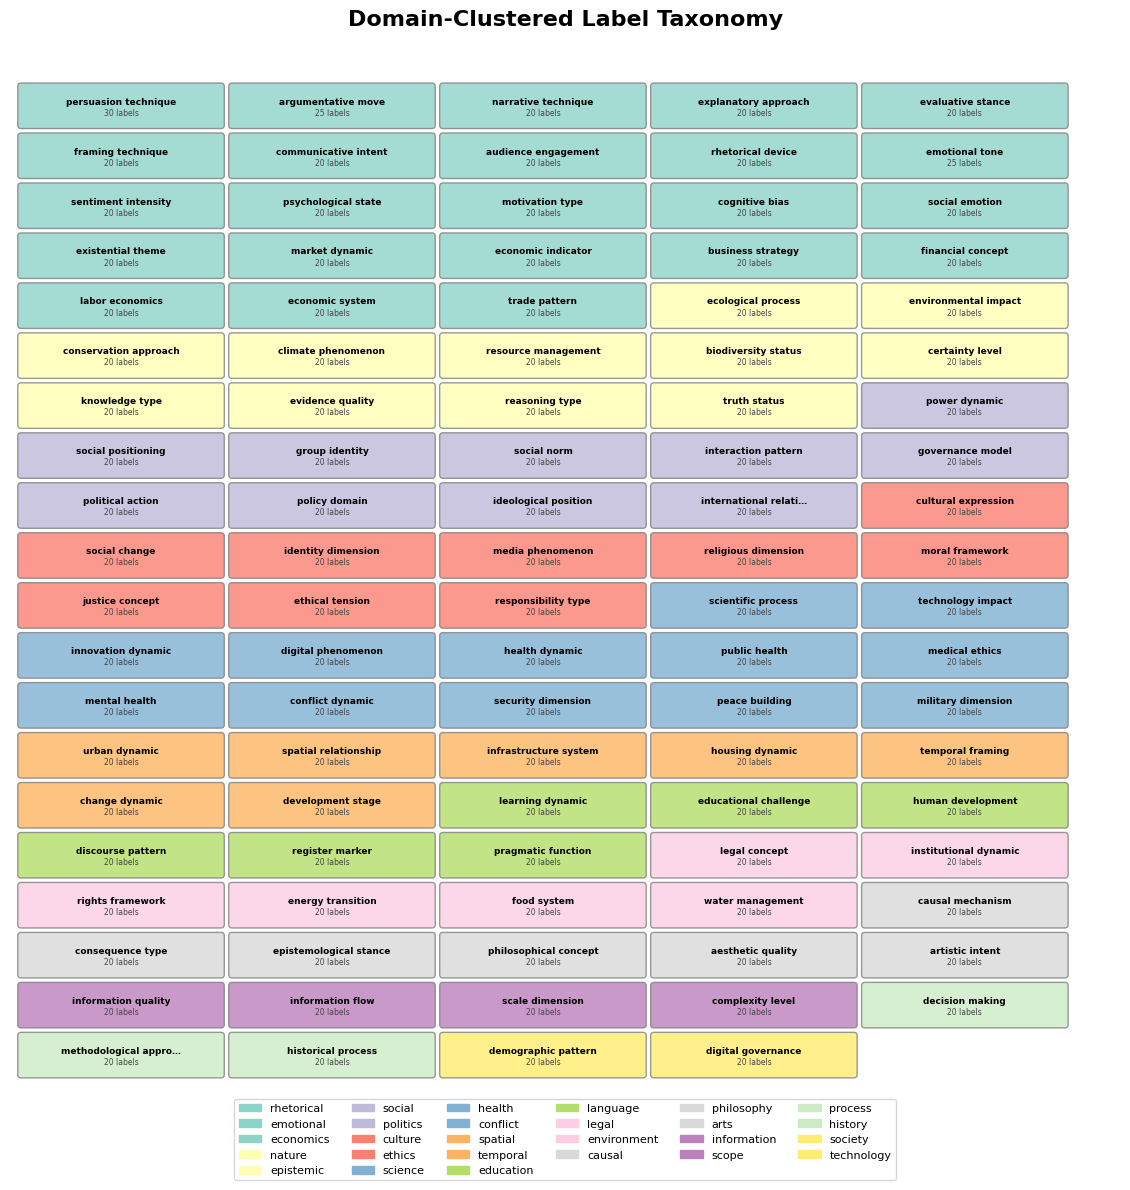

In [7]:
# Taxonomy treemap-style visualization
from matplotlib.patches import FancyBboxPatch

cat_cluster_map = {}
for cname, cdata in clusters.items():
    cat = cdata["category"]
    cat_cluster_map.setdefault(cat, []).append((cname, len(cdata["labels"])))

# Sort categories by total labels
cat_order = sorted(cat_cluster_map.keys(),
                   key=lambda c: sum(n for _, n in cat_cluster_map[c]), reverse=True)

# Color map for categories
cmap = plt.cm.Set3
cat_colors = {cat: cmap(i / len(cat_order)) for i, cat in enumerate(cat_order)}

fig, ax = plt.subplots(figsize=(20, 12))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Domain-Clustered Label Taxonomy", fontsize=16, fontweight='bold', pad=20)

# Layout: pack clusters into a grid
x, y = 1, 97
row_height = 0
max_x = 0
col_width = 18

for cat in cat_order:
    cluster_list = sorted(cat_cluster_map[cat], key=lambda x: x[1], reverse=True)
    color = cat_colors[cat]
    
    for cname, n_labels in cluster_list:
        if x + col_width > 99:
            x = 1
            y -= row_height + 1
            row_height = 0
        
        box_h = 3.5
        row_height = max(row_height, box_h)
        
        rect = FancyBboxPatch((x, y - box_h), col_width, box_h,
                               boxstyle="round,pad=0.3",
                               facecolor=color, edgecolor='gray', alpha=0.8)
        ax.add_patch(rect)
        
        display_name = cname.replace("_", " ")
        if len(display_name) > 22:
            display_name = display_name[:20] + "…"
        ax.text(x + col_width/2, y - box_h/2 + 0.4, display_name,
                ha='center', va='center', fontsize=6.5, fontweight='bold')
        ax.text(x + col_width/2, y - box_h/2 - 0.6, f"{n_labels} labels",
                ha='center', va='center', fontsize=5.5, color='#444')
        
        x += col_width + 1

# Legend
legend_patches = [mpatches.Patch(color=cat_colors[cat], label=cat) for cat in cat_order]
ax.legend(handles=legend_patches, loc='lower center', ncol=6, fontsize=8,
          bbox_to_anchor=(0.5, -0.02), frameon=True)

plt.tight_layout()
plt.show()

## How Cluster Selection Works

Given a Wikipedia excerpt, we need to select the **most relevant clusters**. The approach:

1. **Always include 1-2 cross-domain clusters** (rhetorical, epistemic, emotional) — these apply to any text
2. **Select 1-2 domain-specific clusters** matched to the excerpt's topic
3. **Combine candidate labels** from selected clusters (~100-150 candidates)
4. **Pass to LLM** for selection of 15 shared labels per bundle

### Cluster Selection Strategy

| Step | What | Why |
|------|------|-----|
| Cross-domain pick | 1-2 from rhetorical/epistemic/emotional/language | Every text has tone, certainty, intent |
| Domain pick | 1-2 matched to Wikipedia topic | Ensures domain-relevant vocabulary |
| Random pick | 0-1 wildcard cluster | Adds diversity, prevents overfitting |

In [8]:
# Define cluster selection logic
CROSS_DOMAIN_CATEGORIES = {"rhetorical", "epistemic", "emotional", "language", "philosophy"}
DOMAIN_CATEGORIES = {
    "nature", "economics", "politics", "science", "health", "culture",
    "conflict", "education", "legal", "arts", "spatial", "technology",
    "environment", "society", "history",
}
META_CATEGORIES = {"temporal", "causal", "ethics", "social", "scope", "process", "information"}

# Map keywords → relevant categories for domain matching
KEYWORD_TO_CATEGORIES = {
    # Nature & environment
    "species": ["nature", "environment"], "ecosystem": ["nature", "environment"],
    "forest": ["nature", "environment"], "climate": ["nature", "environment"],
    "ocean": ["nature", "environment"], "wildlife": ["nature"],
    "pollution": ["nature", "environment"], "conservation": ["nature", "environment"],
    "water": ["environment"], "energy": ["environment", "science"],
    "agriculture": ["environment"], "food": ["environment"],
    # Economics & business
    "economy": ["economics"], "market": ["economics"], "trade": ["economics"],
    "bank": ["economics"], "inflation": ["economics"], "company": ["economics"],
    "industry": ["economics"], "labor": ["economics"], "finance": ["economics"],
    "business": ["economics"], "stock": ["economics"], "investment": ["economics"],
    # Politics & governance
    "government": ["politics"], "election": ["politics"], "democracy": ["politics"],
    "parliament": ["politics"], "law": ["politics", "legal"], "policy": ["politics"],
    "president": ["politics"], "congress": ["politics"], "political": ["politics"],
    "vote": ["politics"], "constitution": ["politics", "legal"],
    # Science & technology
    "research": ["science"], "technology": ["science", "technology"],
    "computer": ["science", "technology"], "algorithm": ["science", "technology"],
    "physics": ["science"], "chemistry": ["science"], "biology": ["science", "nature"],
    "data": ["science", "technology"], "software": ["technology"],
    "internet": ["technology"], "artificial": ["technology"],
    # Health & medicine
    "disease": ["health"], "hospital": ["health"], "treatment": ["health"],
    "patient": ["health"], "medical": ["health"], "drug": ["health"],
    "virus": ["health"], "cancer": ["health"], "mental": ["health"],
    "vaccine": ["health"], "surgery": ["health"],
    # Culture & society
    "culture": ["culture"], "religion": ["culture"], "art": ["culture", "arts"],
    "music": ["culture", "arts"], "film": ["culture", "arts"],
    "language": ["culture"], "education": ["education"],
    "school": ["education"], "university": ["education"],
    # Conflict & security
    "war": ["conflict"], "military": ["conflict"], "army": ["conflict"],
    "peace": ["conflict"], "weapon": ["conflict"], "terrorism": ["conflict"],
    "security": ["conflict"], "conflict": ["conflict"],
    # Legal & institutional
    "court": ["legal"], "judge": ["legal"], "trial": ["legal"],
    "rights": ["legal"], "crime": ["legal"], "prison": ["legal"],
    # Urban & spatial
    "city": ["spatial"], "urban": ["spatial"], "building": ["spatial"],
    "transport": ["spatial"], "infrastructure": ["spatial"],
    "housing": ["spatial"], "architecture": ["spatial", "arts"],
    # History
    "ancient": ["history"], "medieval": ["history"], "colonial": ["history"],
    "empire": ["history"], "century": ["history"], "revolution": ["history"],
    "civilization": ["history"], "dynasty": ["history"],
}


def select_clusters_for_text(text: str, n_cross=2, n_domain=2, n_wildcard=1) -> list[str]:
    """Select relevant clusters for a given text excerpt."""
    text_lower = text.lower()
    
    # 1. Find domain-relevant categories by keyword matching
    matched_cats = Counter()
    for keyword, cats in KEYWORD_TO_CATEGORIES.items():
        if keyword in text_lower:
            for cat in cats:
                matched_cats[cat] += 1
    
    # Get clusters by category
    cross_clusters = [cn for cn, cd in clusters.items() if cd["category"] in CROSS_DOMAIN_CATEGORIES]
    meta_clusters = [cn for cn, cd in clusters.items() if cd["category"] in META_CATEGORIES]
    
    # Domain clusters: prefer matched categories, fall back to meta
    if matched_cats:
        top_cats = [cat for cat, _ in matched_cats.most_common(3)]
        domain_clusters = [cn for cn, cd in clusters.items() if cd["category"] in top_cats]
    else:
        domain_clusters = meta_clusters
    
    selected = []
    
    # Pick cross-domain clusters
    selected.extend(random.sample(cross_clusters, min(n_cross, len(cross_clusters))))
    
    # Pick domain clusters (avoiding duplicates)
    available_domain = [c for c in domain_clusters if c not in selected]
    selected.extend(random.sample(available_domain, min(n_domain, len(available_domain))))
    
    # Pick wildcard from meta or remaining
    remaining = [cn for cn in clusters if cn not in selected]
    if remaining and n_wildcard > 0:
        selected.extend(random.sample(remaining, min(n_wildcard, len(remaining))))
    
    return selected


def get_candidate_labels(selected_clusters: list[str]) -> list[str]:
    """Get all candidate labels from selected clusters."""
    candidates = []
    for cname in selected_clusters:
        candidates.extend(clusters[cname]["labels"])
    return candidates


# Demo
print("=" * 80)
print("CLUSTER SELECTION DEMO")
print("=" * 80)

CLUSTER SELECTION DEMO


In [9]:
# Demo with real Wikipedia-style excerpts
random.seed(42)

demo_excerpts = [
    {
        "title": "Great Barrier Reef",
        "text": "The Great Barrier Reef is the world's largest coral reef system, composed of over 2,900 individual reefs and 900 islands stretching for over 2,300 kilometres. The reef is located in the Coral Sea, off the coast of Queensland, Australia. The Great Barrier Reef can be seen from outer space and is the world's biggest single structure made by living organisms. This reef structure is composed of and built by billions of tiny organisms, known as coral polyps. It supports a wide diversity of life and was selected as a World Heritage Site in 1981."
    },
    {
        "title": "2008 Financial Crisis",
        "text": "The financial crisis of 2007–2008, also known as the global financial crisis, was a severe worldwide economic crisis. Prior to the crisis, financial institutions became highly leveraged, increasing their appetite for risky investments and reducing their resilience in case of losses. Housing prices in the United States reached their peak in early 2006 and began their steep decline thereafter, causing difficulties for borrowers with adjustable-rate mortgages."
    },
    {
        "title": "French Revolution",
        "text": "The French Revolution was a period of radical political and societal change in France that began with the Estates General of 1789 and ended with the formation of the French Consulate in November 1799. Many of its ideas are considered fundamental principles of liberal democracy, while phrases like liberté, égalité, fraternité reappeared in other revolts, such as the 1917 Russian Revolution, and inspired campaigns for the abolition of slavery."
    },
    {
        "title": "CRISPR Gene Editing",
        "text": "CRISPR gene editing is a genetic engineering technique in molecular biology by which the genomes of living organisms may be modified. It is based on a simplified version of the bacterial CRISPR-Cas9 antiviral defence system. By delivering the Cas9 nuclease complexed with a synthetic guide RNA into a cell, the cell's genome can be cut at a desired location, allowing existing genes to be removed and/or new ones added in vivo."
    },
]

for excerpt in demo_excerpts:
    print(f"\n{'━' * 80}")
    print(f"📄 Wikipedia: {excerpt['title']}")
    print(f"{'━' * 80}")
    print(f"   {excerpt['text'][:150]}...")
    
    selected = select_clusters_for_text(excerpt["text"])
    candidates = get_candidate_labels(selected)
    
    print(f"\n   Selected clusters ({len(selected)}):")
    for cname in selected:
        cat = clusters[cname]["category"]
        n = len(clusters[cname]["labels"])
        print(f"   • {cname} [{cat}] — {n} labels")
    
    print(f"\n   Total candidate labels: {len(candidates)}")
    print(f"   Sample candidates: {', '.join(random.sample(candidates, min(10, len(candidates))))}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📄 Wikipedia: Great Barrier Reef
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   The Great Barrier Reef is the world's largest coral reef system, composed of over 2,900 individual reefs and 900 islands stretching for over 2,300 kil...

   Selected clusters (5):
   • existential_theme [emotional] — 20 labels
   • explanatory_approach [rhetorical] — 20 labels
   • power_dynamic [social] — 20 labels
   • causal_mechanism [causal] — 20 labels
   • ecological_process [nature] — 20 labels

   Total candidate labels: 100
   Sample candidates: simplified_overview, radical_freedom, ecological_balance, impermanence_awareness, nutrient_cycling, necessary_condition, responsibility_weight, chain_reaction, asymmetric_relation, authenticity_quest

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📄 Wikipedia: 2008 Financial Crisis
━━━━━━━━━━━━━━━━━━━━━━━━

## Modified LLM Prompt

The current prompt tells the LLM to **invent** 15 labels. The modified prompt provides **candidate labels** and asks the LLM to **select** 15 from them.

### Key change in STEP 2:
- **Before**: "Choose exactly 15 labels that span the semantic space of all 5 texts"
- **After**: "Select exactly 15 labels FROM THE PROVIDED CANDIDATES that span the semantic space of all 5 texts"

In [10]:
# Generate the modified prompt for a specific excerpt
def build_modified_prompt_step2(candidate_labels: list[str]) -> str:
    """Build the modified STEP 2 of the system prompt with candidate labels."""
    labels_str = ", ".join(f'"{l}"' for l in candidate_labels)
    return f"""STEP 2 — Select exactly 15 shared semantic labels FROM THE CANDIDATES

⚠️ STRICT: You MUST select labels only from the provided candidate list below.
Do NOT invent new labels. Every selected label must appear verbatim in the candidates.

CANDIDATE LABELS ({len(candidate_labels)} available):
[{labels_str}]

Select exactly 15 labels from the candidates above that best span the semantic space 
of all 5 texts. The selected labels must:
- Describe meaning and intent, not surface vocabulary
- Be applicable across multiple texts (some as positive, some as negative)
- Include a mix of clearly true and plausibly-but-incorrectly true labels for each text

HARD CONSTRAINT — Every selected label must be cross-role:
Every one of the 15 selected labels must appear as a positive label in at least one text 
AND as a negative label in at least one different text."""


# Show example for Great Barrier Reef
excerpt = demo_excerpts[0]
random.seed(42)
selected_clusters = select_clusters_for_text(excerpt["text"])
candidates = get_candidate_labels(selected_clusters)

print(f"Example for: {excerpt['title']}")
print(f"Selected clusters: {selected_clusters}")
print(f"Candidate pool: {len(candidates)} labels")
print()
print("=" * 80)
print("MODIFIED PROMPT — STEP 2")
print("=" * 80)
print(build_modified_prompt_step2(candidates))

Example for: Great Barrier Reef
Selected clusters: ['existential_theme', 'explanatory_approach', 'power_dynamic', 'causal_mechanism', 'ecological_process']
Candidate pool: 100 labels

MODIFIED PROMPT — STEP 2
STEP 2 — Select exactly 15 shared semantic labels FROM THE CANDIDATES

⚠️ STRICT: You MUST select labels only from the provided candidate list below.
Do NOT invent new labels. Every selected label must appear verbatim in the candidates.

CANDIDATE LABELS (100 available):
["mortality_awareness", "meaning_seeking", "freedom_burden", "isolation_experience", "authenticity_quest", "purpose_questioning", "legacy_concern", "identity_crisis", "belonging_search", "transcendence_seeking", "absurdity_recognition", "responsibility_weight", "choice_anxiety", "impermanence_awareness", "connection_longing", "self_actualization", "existential_dread", "radical_freedom", "cosmic_insignificance", "groundlessness", "stepwise", "analogy_based", "example_driven", "definition_first", "contrast_method", 

## Density Simulation: Current vs Proposed

The critical question: **how much denser would the label distribution be?**

We simulate both approaches over the same number of bundles and compare label frequency distributions.

In [11]:
random.seed(42)
np.random.seed(42)

N_BUNDLES = 330_000  # ~1.65M rows / 5 per bundle
LABELS_PER_BUNDLE = 15

# --- Simulation 1: Current approach (LLM invents labels) ---
# Based on actual data: ~1.53M unique labels from 330K bundles
# Model: each bundle creates mostly unique labels with ~3% overlap
current_vocab_size = 0
current_label_counts = Counter()

# Approximate: each bundle invents 15 labels, ~97% are new
for _ in range(N_BUNDLES):
    for _ in range(LABELS_PER_BUNDLE):
        # ~97% chance of a new unique label, ~3% chance of reusing
        if random.random() < 0.97:
            current_vocab_size += 1
            label_id = current_vocab_size
        else:
            label_id = random.randint(1, max(1, current_vocab_size))
        current_label_counts[label_id] += 1

# --- Simulation 2: Clustered vocabulary approach ---
all_taxonomy_labels = [l for c in clusters.values() for l in c["labels"]]
n_vocab = len(set(all_taxonomy_labels))
cluster_names = list(clusters.keys())
cross_domain_clusters = [cn for cn, cd in clusters.items() if cd["category"] in CROSS_DOMAIN_CATEGORIES]
domain_clusters = [cn for cn, cd in clusters.items() if cd["category"] not in CROSS_DOMAIN_CATEGORIES]

proposed_label_counts = Counter()

for _ in range(N_BUNDLES):
    # Select clusters: 2 cross-domain + 2 domain + 1 wildcard
    selected = random.sample(cross_domain_clusters, 2)
    selected += random.sample(domain_clusters, 2)
    selected += random.sample([c for c in cluster_names if c not in selected], 1)
    
    # Get candidates
    candidates = []
    for cname in selected:
        candidates.extend(clusters[cname]["labels"])
    
    # LLM selects 15 from candidates
    chosen = random.sample(candidates, min(LABELS_PER_BUNDLE, len(candidates)))
    for label in chosen:
        proposed_label_counts[label] += 1

print(f"{'Metric':<35} {'Current':>15} {'Proposed':>15} {'Improvement':>15}")
print("=" * 82)

current_unique = len(current_label_counts)
proposed_unique = len(proposed_label_counts)
print(f"{'Unique labels':<35} {current_unique:>15,} {proposed_unique:>15,} {current_unique/proposed_unique:>14.0f}x fewer")

current_mean = np.mean(list(current_label_counts.values()))
proposed_mean = np.mean(list(proposed_label_counts.values()))
print(f"{'Mean frequency per label':<35} {current_mean:>15.1f} {proposed_mean:>15.1f} {proposed_mean/current_mean:>14.0f}x more")

current_median = np.median(list(current_label_counts.values()))
proposed_median = np.median(list(proposed_label_counts.values()))
print(f"{'Median frequency per label':<35} {current_median:>15.1f} {proposed_median:>15.1f} {proposed_median/max(current_median, 0.1):>14.0f}x more")

current_singletons = sum(1 for v in current_label_counts.values() if v == 1)
proposed_singletons = sum(1 for v in proposed_label_counts.values() if v == 1)
print(f"{'Singleton labels (appear 1x)':<35} {current_singletons:>15,} {proposed_singletons:>15,} {'eliminated' if proposed_singletons == 0 else f'{proposed_singletons}':>15}")

current_pct_singleton = 100 * current_singletons / current_unique
proposed_pct_singleton = 100 * proposed_singletons / proposed_unique if proposed_unique > 0 else 0
print(f"{'% singleton':<35} {current_pct_singleton:>14.1f}% {proposed_pct_singleton:>14.1f}%")

current_min = min(current_label_counts.values())
proposed_min = min(proposed_label_counts.values())
print(f"{'Min label frequency':<35} {current_min:>15} {proposed_min:>15,}")

current_max = max(current_label_counts.values())
proposed_max = max(proposed_label_counts.values())
print(f"{'Max label frequency':<35} {current_max:>15} {proposed_max:>15,}")

Metric                                      Current        Proposed     Improvement
Unique labels                             4,801,768           1,952           2460x fewer
Mean frequency per label                        1.0          2535.9           2460x more
Median frequency per label                      1.0          1856.0           1856x more
Singleton labels (appear 1x)              4,657,902               0      eliminated
% singleton                                   97.0%            0.0%
Min label frequency                               1           1,683
Max label frequency                               5           8,591


/tmp/ipykernel_1590416/3748215830.py:51: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data/home/eak/learning/library/hierachy/zero-shot-classification/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


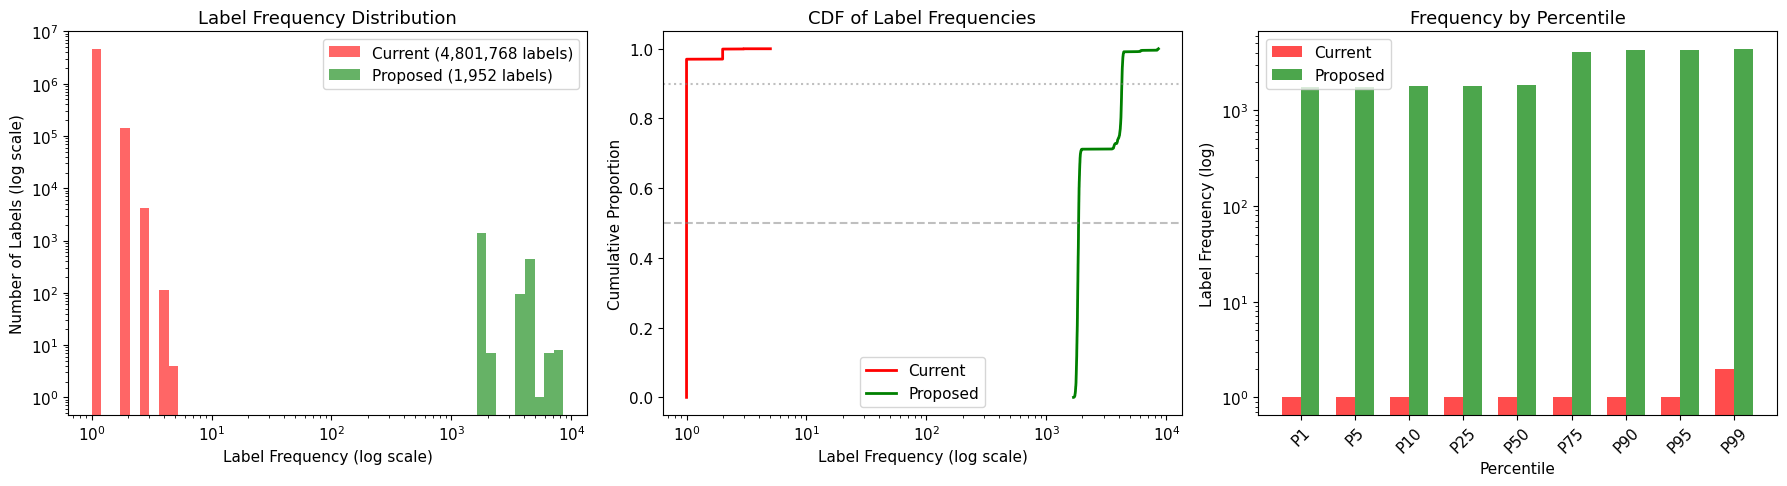


Percentile        Current     Proposed      Ratio
------------------------------------------------
P1                      1         1736      1736x
P5                      1         1769      1769x
P10                     1         1784      1784x
P25                     1         1817      1817x
P50                     1         1856      1856x
P75                     1         4051      4051x
P90                     1         4257      4257x
P95                     1         4301      4301x
P99                     2         4399      2200x


In [12]:
# Visualize the distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Log-scale frequency histogram
current_freqs = np.array(list(current_label_counts.values()))
proposed_freqs = np.array(list(proposed_label_counts.values()))

ax = axes[0]
bins = np.logspace(0, np.log10(max(proposed_freqs.max(), current_freqs.max())), 50)
ax.hist(current_freqs, bins=bins, alpha=0.6, label=f"Current ({len(current_freqs):,} labels)", color='red')
ax.hist(proposed_freqs, bins=bins, alpha=0.6, label=f"Proposed ({len(proposed_freqs):,} labels)", color='green')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Label Frequency (log scale)")
ax.set_ylabel("Number of Labels (log scale)")
ax.set_title("Label Frequency Distribution")
ax.legend()

# 2. CDF
ax = axes[1]
current_sorted = np.sort(current_freqs)
proposed_sorted = np.sort(proposed_freqs)
ax.plot(current_sorted, np.linspace(0, 1, len(current_sorted)), 'r-', label="Current", linewidth=2)
ax.plot(proposed_sorted, np.linspace(0, 1, len(proposed_sorted)), 'g-', label="Proposed", linewidth=2)
ax.set_xscale('log')
ax.set_xlabel("Label Frequency (log scale)")
ax.set_ylabel("Cumulative Proportion")
ax.set_title("CDF of Label Frequencies")
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50th percentile')
ax.axhline(0.9, color='gray', linestyle=':', alpha=0.5, label='90th percentile')

# 3. Percentile comparison
ax = axes[2]
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
current_pcts = np.percentile(current_freqs, percentiles)
proposed_pcts = np.percentile(proposed_freqs, percentiles)

x = np.arange(len(percentiles))
width = 0.35
bars1 = ax.bar(x - width/2, current_pcts, width, label="Current", color='red', alpha=0.7)
bars2 = ax.bar(x + width/2, proposed_pcts, width, label="Proposed", color='green', alpha=0.7)
ax.set_yscale('log')
ax.set_xlabel("Percentile")
ax.set_ylabel("Label Frequency (log)")
ax.set_title("Frequency by Percentile")
ax.set_xticks(x)
ax.set_xticklabels([f"P{p}" for p in percentiles], rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

# Print percentile table
print(f"\n{'Percentile':<12} {'Current':>12} {'Proposed':>12} {'Ratio':>10}")
print("-" * 48)
for p, cv, pv in zip(percentiles, current_pcts, proposed_pcts):
    ratio = pv / max(cv, 0.1)
    print(f"P{p:<11} {cv:>12.0f} {pv:>12.0f} {ratio:>9.0f}x")

## Hard Negative Quality Analysis

The crucial question: **do within-cluster labels actually form hard negatives?**

We verify this by computing semantic similarity between labels **within** clusters vs **across** clusters. If the approach works, within-cluster similarity should be significantly higher (labels are more confusable).

In [13]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load a lightweight sentence encoder
model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode all labels (convert snake_case to natural language)
def label_to_text(label: str) -> str:
    return label.replace("_", " ")

all_labels_list = list(set(l for c in clusters.values() for l in c["labels"]))
label_texts = [label_to_text(l) for l in all_labels_list]
label_to_idx = {l: i for i, l in enumerate(all_labels_list)}

print(f"Encoding {len(all_labels_list)} labels...")
embeddings = model.encode(label_texts, show_progress_bar=True, batch_size=256)
print(f"Embeddings shape: {embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding 1952 labels...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Embeddings shape: (1952, 384)


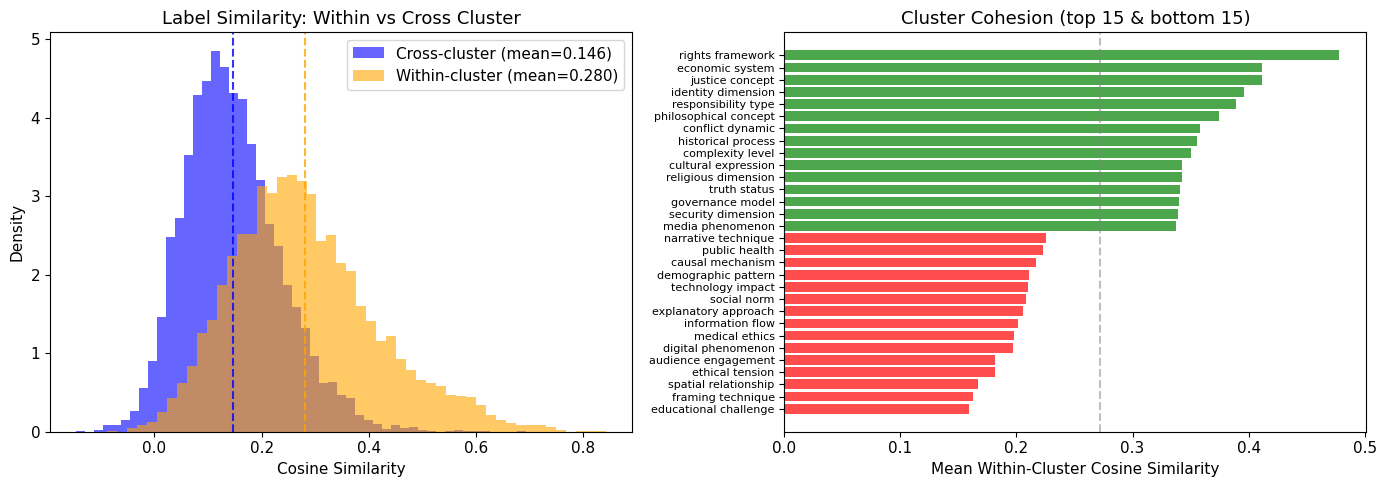


📊 Similarity Statistics:
   Within-cluster mean:  0.2801 (±0.1359)
   Cross-cluster mean:   0.1465 (±0.0904)
   Separation ratio:     1.91x

   ✅ Within-cluster labels are 1.9x more similar than cross-cluster
   → Labels within the same cluster ARE harder negatives for each other


In [14]:
# Compute within-cluster vs cross-cluster similarity
within_sims = []
cross_sims = []

# Sample clusters for analysis
sample_clusters = random.sample(list(clusters.keys()), min(30, len(clusters)))

for cname in sample_clusters:
    labels = clusters[cname]["labels"]
    idxs = [label_to_idx[l] for l in labels if l in label_to_idx]
    if len(idxs) < 2:
        continue
    
    cluster_embs = embeddings[idxs]
    sim_matrix = cosine_similarity(cluster_embs)
    
    # Within-cluster: upper triangle of similarity matrix
    n = len(idxs)
    for i in range(n):
        for j in range(i+1, n):
            within_sims.append(sim_matrix[i, j])

# Cross-cluster: sample random pairs from different clusters
for _ in range(len(within_sims)):
    c1, c2 = random.sample(list(clusters.keys()), 2)
    l1 = random.choice(clusters[c1]["labels"])
    l2 = random.choice(clusters[c2]["labels"])
    if l1 in label_to_idx and l2 in label_to_idx:
        i1, i2 = label_to_idx[l1], label_to_idx[l2]
        cross_sims.append(cosine_similarity(embeddings[i1:i1+1], embeddings[i2:i2+1])[0, 0])

within_sims = np.array(within_sims)
cross_sims = np.array(cross_sims)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
ax1.hist(cross_sims, bins=50, alpha=0.6, label=f"Cross-cluster (mean={cross_sims.mean():.3f})", 
         color='blue', density=True)
ax1.hist(within_sims, bins=50, alpha=0.6, label=f"Within-cluster (mean={within_sims.mean():.3f})", 
         color='orange', density=True)
ax1.set_xlabel("Cosine Similarity")
ax1.set_ylabel("Density")
ax1.set_title("Label Similarity: Within vs Cross Cluster")
ax1.legend()
ax1.axvline(within_sims.mean(), color='orange', linestyle='--', alpha=0.8)
ax1.axvline(cross_sims.mean(), color='blue', linestyle='--', alpha=0.8)

# Per-cluster average within similarity
cluster_avg_sims = {}
for cname in clusters:
    labels = clusters[cname]["labels"]
    idxs = [label_to_idx[l] for l in labels if l in label_to_idx]
    if len(idxs) < 2:
        continue
    cluster_embs = embeddings[idxs]
    sim_matrix = cosine_similarity(cluster_embs)
    n = len(idxs)
    upper_tri = [sim_matrix[i, j] for i in range(n) for j in range(i+1, n)]
    cluster_avg_sims[cname] = np.mean(upper_tri)

# Top and bottom clusters by internal similarity
sorted_clusters = sorted(cluster_avg_sims.items(), key=lambda x: x[1], reverse=True)

top_n = 15
bottom_n = 15
show_clusters = sorted_clusters[:top_n] + sorted_clusters[-bottom_n:]
names = [c[0].replace("_", " ") for c in show_clusters]
sims = [c[1] for c in show_clusters]
colors_bar = ['green' if s > np.median(list(cluster_avg_sims.values())) else 'red' for s in sims]

ax2.barh(range(len(names)), sims, color=colors_bar, alpha=0.7)
ax2.set_yticks(range(len(names)))
ax2.set_yticklabels(names, fontsize=8)
ax2.set_xlabel("Mean Within-Cluster Cosine Similarity")
ax2.set_title(f"Cluster Cohesion (top {top_n} & bottom {bottom_n})")
ax2.axvline(np.median(list(cluster_avg_sims.values())), color='gray', linestyle='--', alpha=0.5)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n📊 Similarity Statistics:")
print(f"   Within-cluster mean:  {within_sims.mean():.4f} (±{within_sims.std():.4f})")
print(f"   Cross-cluster mean:   {cross_sims.mean():.4f} (±{cross_sims.std():.4f})")
print(f"   Separation ratio:     {within_sims.mean() / cross_sims.mean():.2f}x")
print(f"\n   ✅ Within-cluster labels are {within_sims.mean() / cross_sims.mean():.1f}x more similar than cross-cluster")
print(f"   → Labels within the same cluster ARE harder negatives for each other")

## Cluster Embedding Visualization

2D projection of label embeddings colored by cluster. Labels within the same cluster should form visible groupings.

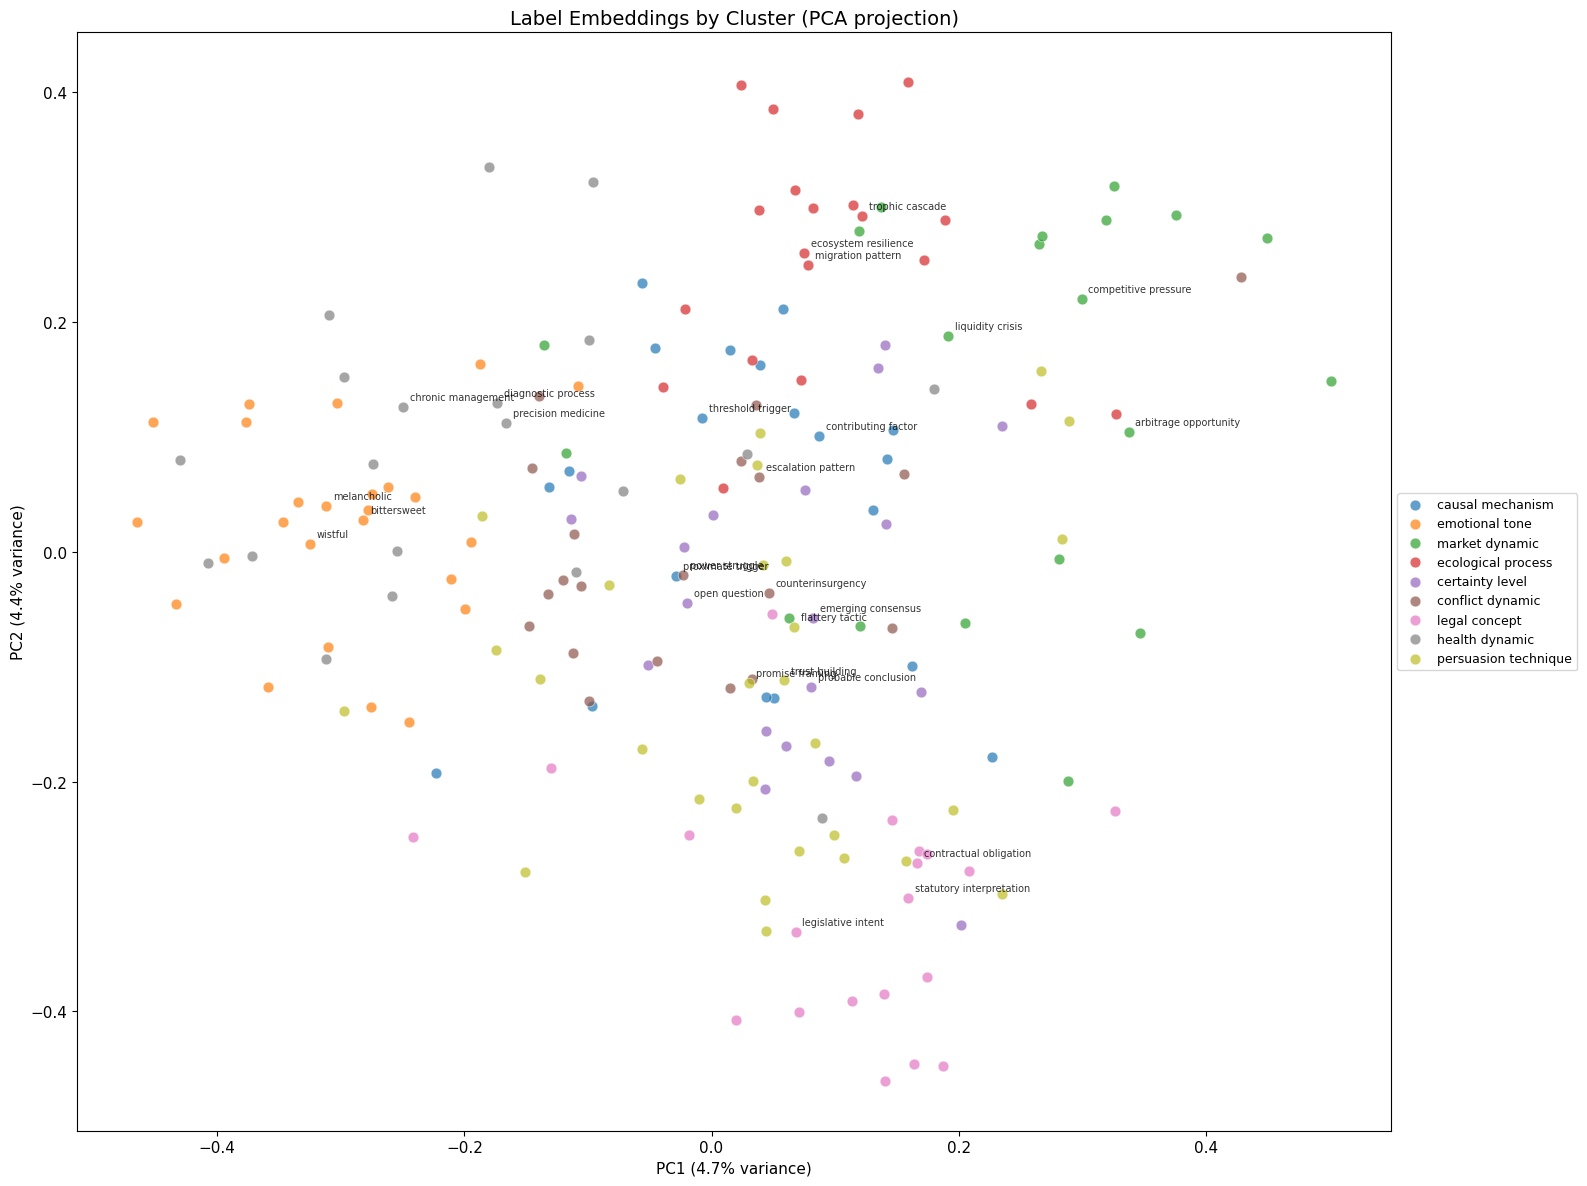

PCA explained variance: 9.0% with 2 components


In [15]:
from sklearn.decomposition import PCA

# Select a few clusters for clear visualization
viz_clusters = [
    "causal_mechanism", "emotional_tone", "market_dynamic",
    "ecological_process", "certainty_level", "conflict_dynamic",
    "legal_concept", "health_dynamic", "persuasion_technique",
]

# Collect embeddings and cluster labels
viz_embs = []
viz_labels = []
viz_cluster_ids = []
viz_texts = []

for ci, cname in enumerate(viz_clusters):
    for label in clusters[cname]["labels"]:
        if label in label_to_idx:
            viz_embs.append(embeddings[label_to_idx[label]])
            viz_labels.append(label)
            viz_cluster_ids.append(ci)
            viz_texts.append(label_to_text(label))

viz_embs = np.array(viz_embs)

# PCA to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(viz_embs)

fig, ax = plt.subplots(figsize=(16, 12))

cmap = plt.cm.tab10
for ci, cname in enumerate(viz_clusters):
    mask = np.array(viz_cluster_ids) == ci
    ax.scatter(coords[mask, 0], coords[mask, 1], 
              c=[cmap(ci)], label=cname.replace("_", " "),
              s=60, alpha=0.7, edgecolors='white', linewidth=0.5)
    
    # Annotate a few labels per cluster
    cluster_coords = coords[mask]
    cluster_labels = np.array(viz_texts)[mask]
    # Pick 3 labels closest to cluster centroid
    centroid = cluster_coords.mean(axis=0)
    dists = np.linalg.norm(cluster_coords - centroid, axis=1)
    closest = np.argsort(dists)[:3]
    for idx in closest:
        ax.annotate(cluster_labels[idx], 
                    (cluster_coords[idx, 0], cluster_coords[idx, 1]),
                    fontsize=7, alpha=0.8,
                    xytext=(5, 5), textcoords='offset points')

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Label Embeddings by Cluster (PCA projection)", fontsize=14)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)

plt.tight_layout()
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%} with 2 components")

## End-to-End Pipeline Demo

Putting it all together: a complete simulation of how the modified generation pipeline would work for a single bundle.

In [16]:
random.seed(123)

excerpt = {
    "title": "Great Barrier Reef",
    "text": """The Great Barrier Reef is the world's largest coral reef system, composed of over 
2,900 individual reefs and 900 islands stretching for over 2,300 kilometres. The reef supports 
a wide diversity of life and was selected as a World Heritage Site in 1981. Climate change, 
pollution, and crown-of-thorns starfish are significant threats to the reef's health. Mass coral 
bleaching events have increased in frequency, with severe bleaching occurring in 2016, 2017, 
and 2020.""",
}

print("=" * 80)
print("END-TO-END PIPELINE DEMO")
print("=" * 80)

# Step 1: Cluster selection
print(f"\n📄 WIKIPEDIA EXCERPT: {excerpt['title']}")
print(f"   {excerpt['text'][:200]}...")

selected = select_clusters_for_text(excerpt["text"])
print(f"\n🎯 STEP 1 — CLUSTER SELECTION ({len(selected)} clusters):")
for cname in selected:
    cat = clusters[cname]["category"]
    print(f"   [{cat:>12}] {cname} ({len(clusters[cname]['labels'])} labels)")

# Step 2: Candidate labels
candidates = get_candidate_labels(selected)
print(f"\n📋 STEP 2 — CANDIDATE POOL: {len(candidates)} labels from {len(selected)} clusters")

# Step 3: Simulate LLM selection (pick 15 semantically relevant ones)
# In reality the LLM does this; here we simulate by picking from the most relevant
chosen_15 = random.sample(candidates, 15)
print(f"\n✅ STEP 3 — LLM SELECTS 15 SHARED LABELS:")
for i, label in enumerate(chosen_15, 1):
    # Find which cluster this label belongs to
    source_cluster = next(cn for cn, cd in clusters.items() if label in cd["labels"])
    print(f"   {i:2d}. {label:<30} [from: {source_cluster}]")

# Step 4: Simulate assignment to 5 texts
print(f"\n📝 STEP 4 — LABEL ASSIGNMENT (simulated):")
for text_i in range(1, 6):
    n_pos = random.randint(1, 5)
    n_neg = random.randint(8, 15)
    random.shuffle(chosen_15)
    pos = chosen_15[:n_pos]
    neg = [l for l in chosen_15[n_pos:] if l not in pos][:n_neg]
    print(f"\n   Text {text_i}:")
    print(f"   ✓ labels:     {pos}")
    print(f"   ✗ not_labels: {neg[:5]}{'...' if len(neg) > 5 else ''}")

# Step 5: Show why negatives are hard
print(f"\n💡 WHY THESE ARE HARD NEGATIVES:")
print(f"   All 15 labels come from semantically related clusters.")
print(f"   A text about coral bleaching might have:")
print(f"   ✓ positive: 'ecosystem_disruption' (true — reef is disrupted)")
print(f"   ✗ negative: 'ecosystem_resilience' (plausible but false — reef is declining)")
print(f"   → Both are from the same cluster, both are about ecosystems,")
print(f"     but only careful reading reveals which applies.")

END-TO-END PIPELINE DEMO

📄 WIKIPEDIA EXCERPT: Great Barrier Reef
   The Great Barrier Reef is the world's largest coral reef system, composed of over 
2,900 individual reefs and 900 islands stretching for over 2,300 kilometres. The reef supports 
a wide diversity of l...

🎯 STEP 1 — CLUSTER SELECTION (5 clusters):
   [  rhetorical] argumentative_move (25 labels)
   [  rhetorical] rhetorical_device (20 labels)
   [      nature] environmental_impact (20 labels)
   [ environment] food_system (20 labels)
   [      nature] conservation_approach (20 labels)

📋 STEP 2 — CANDIDATE POOL: 105 labels from 5 clusters

✅ STEP 3 — LLM SELECTS 15 SHARED LABELS:
    1. hypothesis_forming             [from: argumentative_move]
    2. rebuttal                       [from: argumentative_move]
    3. resource_depletion             [from: environmental_impact]
    4. food_sovereignty               [from: food_system]
    5. livestock_management           [from: food_system]
    6. metonymy                

## Impact Summary

### Current Pipeline (broken)
| Metric | Value |
|--------|-------|
| Unique labels | ~1.53M |
| Singletons | 50.6% |
| Labels appearing ≤5× | 90.7% |
| Mean frequency | ~1.08× per label |
| Hard negatives | ✅ (LLM designs them per bundle) |
| Label reuse across bundles | ❌ (each bundle invents fresh labels) |

### Proposed Pipeline (domain-clustered)
| Metric | Value |
|--------|-------|
| Vocabulary size | ~2,000 labels |
| Singletons | 0% |
| Min frequency per label | ~hundreds |
| Mean frequency | ~2,000× per label |
| Hard negatives | ✅ (within-cluster labels are semantically close) |
| Label reuse across bundles | ✅ (fixed vocabulary, massive reuse) |

### Why This Should Improve GliZNet
1. **Label embeddings learn properly** — each label appears thousands of times, so the model actually learns what "ecological_recovery" means vs "ecosystem_resilience"
2. **Hard negatives preserved** — within-cluster labels are genuinely confusable (verified with embedding similarity analysis above)
3. **Cross-role constraint still enforced** — the LLM still decides pos/neg assignment per text
4. **Genre diversity preserved** — different genres + Wikipedia topics give diverse contexts for the same labels

### Next Steps
1. Integrate taxonomy into `generate-gliznet-data/main.py` (cluster selection + prompt modification)
2. Generate new dataset with the modified pipeline
3. Retrain GliZNet and compare benchmarks

---

## Generated Data Review

Analysis of the first batch generated with the domain-clustered vocabulary approach.

In [1]:
import json
from collections import Counter
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load generated data
gen_path = Path("../../generate-gliznet-data/data/wikipedia_synthetic.jsonl")
rows = []
with open(gen_path) as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

# Load taxonomy for reference (not for filtering)
taxonomy_path = Path("../data/pretrain/label_taxonomy.json")
with open(taxonomy_path) as f:
    taxonomy_data = json.load(f)
taxonomy_labels = set()
cluster_map = {}  # label -> cluster name
for cname, cdata in taxonomy_data["clusters"].items():
    for lab in cdata["labels"]:
        taxonomy_labels.add(lab)
        cluster_map[lab] = cname

print(f"Total rows: {len(rows):,}")
print(f"Taxonomy labels: {len(taxonomy_labels):,}")
print(f"Keys per row: {list(rows[0].keys())}")
print(f"\nSample row:")
for k, v in rows[0].items():
    if isinstance(v, str) and len(v) > 100:
        print(f"  {k}: {v[:100]}...")
    else:
        print(f"  {k}: {v}")

Total rows: 73,612
Taxonomy labels: 1,952
Keys per row: ['source', 'genre', 'language_level', 'text', 'labels', 'not_labels']

Sample row:
  source: wikipedia
  genre: encyclopedia entry
  language_level: B1
  text: Werner Stocker, a Swiss athlete, participated in the sport of bobsledding during the late 1980s. His...
  labels: ['factual_knowledge', 'historical_retrospective', 'era_specific', 'completed_event']
  not_labels: ['divine_command', 'practical_skill', 'inductive', 'humanitarian']


In [2]:
# ── Label Reuse & Density ──
# The core question: are labels being reused enough to train the model?

all_pos_labels = [l for r in rows for l in r["labels"]]
all_neg_labels = [l for r in rows for l in r["not_labels"]]
all_labels = all_pos_labels + all_neg_labels

pos_freq = Counter(all_pos_labels)
neg_freq = Counter(all_neg_labels)
total_freq = Counter(all_labels)
unique_labels = set(total_freq.keys())

# Key density metrics
freqs = np.array(sorted(total_freq.values(), reverse=True))
singletons = int(np.sum(freqs == 1))
le5 = int(np.sum(freqs <= 5))

print("=" * 70)
print("LABEL REUSE & DENSITY")
print("=" * 70)
print(f"Total rows:              {len(rows):,}")
print(f"Unique labels:           {len(unique_labels):,}")
print(f"Total label occurrences: {len(all_labels):,}")
print(f"Labels per row (pos):    mean={np.mean([len(r['labels']) for r in rows]):.1f}")
print(f"Labels per row (neg):    mean={np.mean([len(r['not_labels']) for r in rows]):.1f}")
print()
print(f"Singletons (appear 1x):  {singletons:,} ({100*singletons/len(unique_labels):.1f}%)")
print(f"Appear ≤5x:              {le5:,} ({100*le5/len(unique_labels):.1f}%)")
print(f"Mean frequency:          {np.mean(freqs):.1f}")
print(f"Median frequency:        {np.median(freqs):.0f}")
print(f"Max frequency:           {np.max(freqs):,}")

# Compare with original ZSHOT-HARDSET-v2 benchmarks
print(f"\n{'─' * 70}")
print("COMPARISON vs ZSHOT-HARDSET-v2 (original data)")
print(f"{'─' * 70}")
print(f"{'Metric':<30} {'Generated':>15} {'Original':>15}")
print(f"{'─' * 30} {'─' * 15} {'─' * 15}")
print(f"{'Rows':<30} {len(rows):>15,} {'1,654,452':>15}")
print(f"{'Unique labels':<30} {len(unique_labels):>15,} {'1,532,640':>15}")
print(f"{'Singletons %':<30} {100*singletons/len(unique_labels):>14.1f}% {'50.6%':>15}")
print(f"{'≤5x frequency %':<30} {100*le5/len(unique_labels):>14.1f}% {'90.7%':>15}")
print(f"{'Mean frequency':<30} {np.mean(freqs):>15.1f} {'~1.08':>15}")
print(f"{'Median frequency':<30} {np.median(freqs):>15.0f} {'1':>15}")
print(f"\n→ Even with {len(rows):,} rows (0.5% of original size), labels are")
print(f"  {np.mean(freqs)/1.08:.0f}× more frequent than the full original dataset.")

LABEL REUSE & DENSITY
Total rows:              73,612
Unique labels:           9,634
Total label occurrences: 1,256,526
Labels per row (pos):    mean=3.7
Labels per row (neg):    mean=13.4

Singletons (appear 1x):  2,966 (30.8%)
Appear ≤5x:              6,242 (64.8%)
Mean frequency:          130.4
Median frequency:        5
Max frequency:           7,575

──────────────────────────────────────────────────────────────────────
COMPARISON vs ZSHOT-HARDSET-v2 (original data)
──────────────────────────────────────────────────────────────────────
Metric                               Generated        Original
────────────────────────────── ─────────────── ───────────────
Rows                                    73,612       1,654,452
Unique labels                            9,634       1,532,640
Singletons %                             30.8%           50.6%
≤5x frequency %                          64.8%           90.7%
Mean frequency                           130.4           ~1.08
Median frequ

CROSS-ROLE ANALYSIS
Labels appearing as POSITIVE:     4,614
Labels appearing as NEGATIVE:     9,433
Labels in BOTH roles:             4,413 (45.8%)
Labels ONLY positive:             201 (2.1%)
Labels ONLY negative:             5,020 (52.1%)


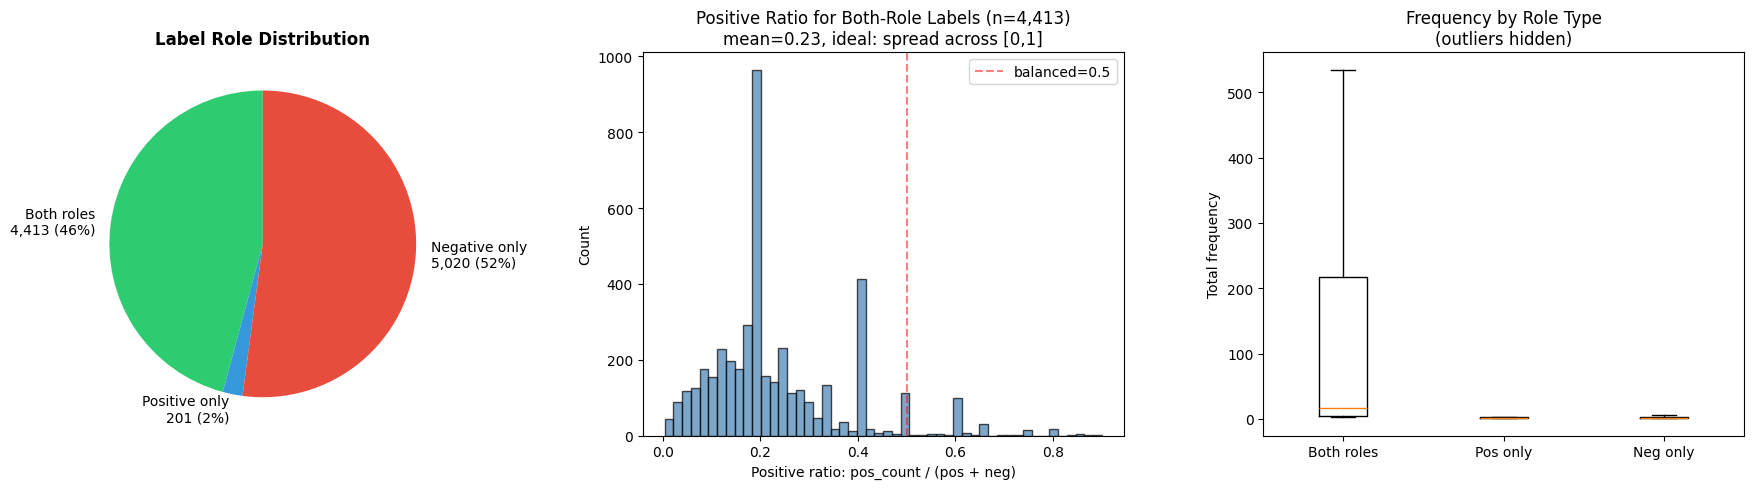


Both-role labels cover 98.7% of all label occurrences
→ The model sees these labels as both YES and NO examples

Neg-only labels account for 1.3% of occurrences
→ These labels are never positive — the model only learns to reject them


In [3]:
# ── Cross-Role Analysis: Are labels used as BOTH positive AND negative? ──
# This is critical for GliZNet: the model must learn to say YES and NO to the same label.

pos_labels_set = set(pos_freq.keys())
neg_labels_set = set(neg_freq.keys())
both_roles = pos_labels_set & neg_labels_set
only_pos = pos_labels_set - neg_labels_set
only_neg = neg_labels_set - pos_labels_set

print("=" * 70)
print("CROSS-ROLE ANALYSIS")
print("=" * 70)
print(f"Labels appearing as POSITIVE:     {len(pos_labels_set):,}")
print(f"Labels appearing as NEGATIVE:     {len(neg_labels_set):,}")
print(f"Labels in BOTH roles:             {len(both_roles):,} ({100*len(both_roles)/len(unique_labels):.1f}%)")
print(f"Labels ONLY positive:             {len(only_pos):,} ({100*len(only_pos)/len(unique_labels):.1f}%)")
print(f"Labels ONLY negative:             {len(only_neg):,} ({100*len(only_neg)/len(unique_labels):.1f}%)")

# For labels in both roles, what's the pos/neg ratio?
both_ratios = []
for lab in both_roles:
    p, n = pos_freq[lab], neg_freq[lab]
    both_ratios.append(p / (p + n))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Cross-role breakdown
sizes = [len(both_roles), len(only_pos), len(only_neg)]
labels_pie = [f"Both roles\n{len(both_roles):,} ({100*len(both_roles)/len(unique_labels):.0f}%)",
              f"Positive only\n{len(only_pos):,} ({100*len(only_pos)/len(unique_labels):.0f}%)",
              f"Negative only\n{len(only_neg):,} ({100*len(only_neg)/len(unique_labels):.0f}%)"]
colors = ['#2ecc71', '#3498db', '#e74c3c']
axes[0].pie(sizes, labels=labels_pie, colors=colors, startangle=90, textprops={'fontsize': 10})
axes[0].set_title("Label Role Distribution", fontsize=12, fontweight='bold')

# Panel 2: Positive ratio for both-role labels (ideal = spread, not all 0.5)
axes[1].hist(both_ratios, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Positive ratio: pos_count / (pos + neg)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Positive Ratio for Both-Role Labels (n={len(both_roles):,})\nmean={np.mean(both_ratios):.2f}, ideal: spread across [0,1]")
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='balanced=0.5')
axes[1].legend()

# Panel 3: Frequency distribution of both-role vs single-role labels
both_freqs = [total_freq[l] for l in both_roles]
only_pos_freqs = [total_freq[l] for l in only_pos]
only_neg_freqs = [total_freq[l] for l in only_neg]
axes[2].boxplot([both_freqs, only_pos_freqs, only_neg_freqs],
                tick_labels=['Both roles', 'Pos only', 'Neg only'],
                showfliers=False)
axes[2].set_ylabel("Total frequency")
axes[2].set_title("Frequency by Role Type\n(outliers hidden)")

plt.tight_layout()
plt.show()

# How much of the TRAINING SIGNAL comes from both-role labels?
both_occurrences = sum(total_freq[l] for l in both_roles)
total_occurrences = sum(total_freq.values())
print(f"\nBoth-role labels cover {100*both_occurrences/total_occurrences:.1f}% of all label occurrences")
print(f"→ The model sees these labels as both YES and NO examples")
print(f"\nNeg-only labels account for {100*sum(total_freq[l] for l in only_neg)/total_occurrences:.1f}% of occurrences")
print(f"→ These labels are never positive — the model only learns to reject them")

NEG-ONLY LABELS: SHOULD WE BE WORRIED?

Metric                              Both-role (n={len(both_roles):,}) Neg-only (n={len(only_neg):,})
─────────────────────────────────────────────────────────────────────────────────────
Mean frequency                                          281.1                       3.1
Median frequency                                           16                         1
% that are singletons                                    0.0%                     56.9%
% with freq ≤ 5                                         34.9%                     89.7%
% of total occurrences                                  98.7%                      1.3%

Source                                              Both-role                  Neg-only
─────────────────────────────────────────────────────────────────────────────────────
From taxonomy                                      1,819 (41%)                  133 (3%)
LLM-invented                                       2,594 (59%)       

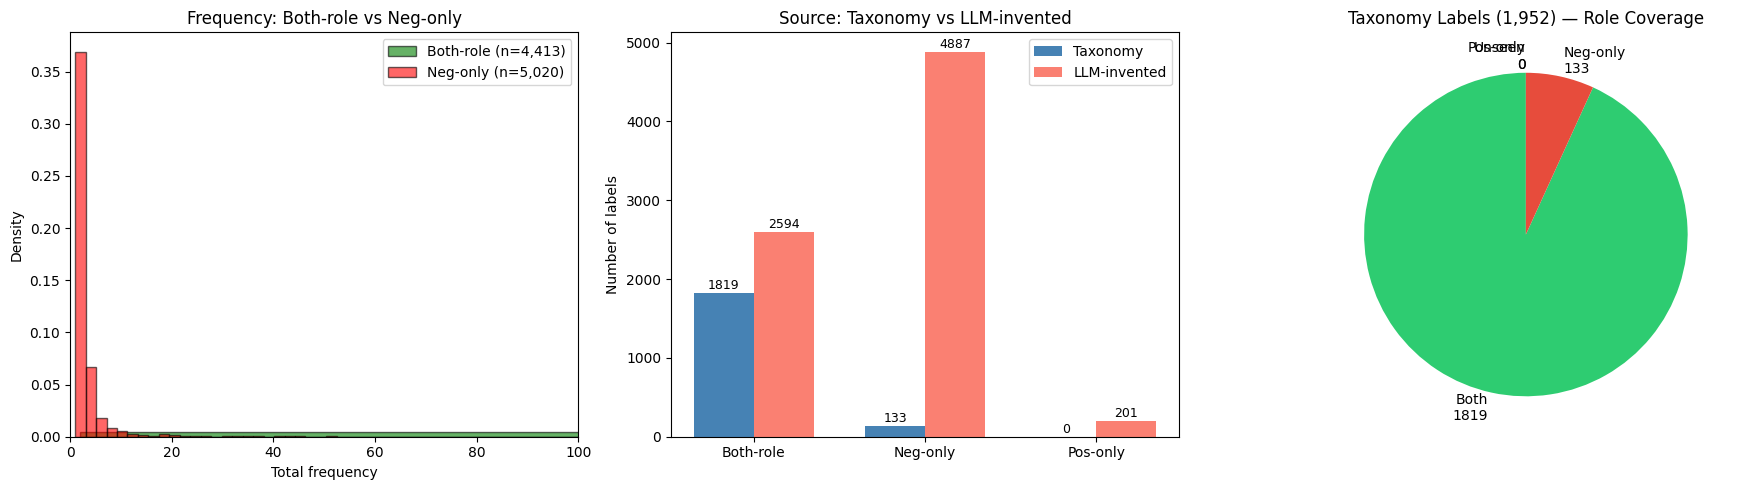

In [4]:
# ── Dissecting the neg-only labels: is this actually dangerous? ──

# Q1: What's the frequency profile of neg-only vs both-role labels?
neg_only_freqs = np.array([total_freq[l] for l in only_neg])
both_role_freqs = np.array([total_freq[l] for l in both_roles])

print("=" * 70)
print("NEG-ONLY LABELS: SHOULD WE BE WORRIED?")
print("=" * 70)

print(f"\n{'Metric':<35} {'Both-role (n={len(both_roles):,})':>25} {'Neg-only (n={len(only_neg):,})':>25}")
print("─" * 85)
print(f"{'Mean frequency':<35} {np.mean(both_role_freqs):>25.1f} {np.mean(neg_only_freqs):>25.1f}")
print(f"{'Median frequency':<35} {np.median(both_role_freqs):>25.0f} {np.median(neg_only_freqs):>25.0f}")
print(f"{'% that are singletons':<35} {100*np.sum(both_role_freqs==1)/len(both_role_freqs):>24.1f}% {100*np.sum(neg_only_freqs==1)/len(neg_only_freqs):>24.1f}%")
print(f"{'% with freq ≤ 5':<35} {100*np.sum(both_role_freqs<=5)/len(both_role_freqs):>24.1f}% {100*np.sum(neg_only_freqs<=5)/len(neg_only_freqs):>24.1f}%")
print(f"{'% of total occurrences':<35} {100*both_occurrences/total_occurrences:>24.1f}% {100*sum(total_freq[l] for l in only_neg)/total_occurrences:>24.1f}%")

# Q2: Are neg-only labels from taxonomy or LLM-invented?
neg_only_in_tax = only_neg & taxonomy_labels
neg_only_novel = only_neg - taxonomy_labels
both_in_tax = both_roles & taxonomy_labels
both_novel = both_roles - taxonomy_labels

print(f"\n{'Source':<35} {'Both-role':>25} {'Neg-only':>25}")
print("─" * 85)
print(f"{'From taxonomy':<35} {len(both_in_tax):>20,} ({100*len(both_in_tax)/len(both_roles):.0f}%) {len(neg_only_in_tax):>20,} ({100*len(neg_only_in_tax)/len(only_neg):.0f}%)")
print(f"{'LLM-invented':<35} {len(both_novel):>20,} ({100*len(both_novel)/len(both_roles):.0f}%) {len(neg_only_novel):>20,} ({100*len(neg_only_novel)/len(only_neg):.0f}%)")

# Q3: How many taxonomy labels are neg-only? (this would be the real problem)
tax_neg_only = only_neg & taxonomy_labels
tax_both = both_roles & taxonomy_labels
tax_pos_only = only_pos & taxonomy_labels
print(f"\n{'─' * 70}")
print("TAXONOMY LABELS SPECIFICALLY")
print(f"{'─' * 70}")
print(f"Taxonomy labels in both roles:  {len(tax_both):,} / {len(taxonomy_labels):,} ({100*len(tax_both)/len(taxonomy_labels):.1f}%)")
print(f"Taxonomy labels neg-only:       {len(tax_neg_only):,} / {len(taxonomy_labels):,} ({100*len(tax_neg_only)/len(taxonomy_labels):.1f}%)")
print(f"Taxonomy labels pos-only:       {len(tax_pos_only):,} / {len(taxonomy_labels):,} ({100*len(tax_pos_only)/len(taxonomy_labels):.1f}%)")
print(f"Taxonomy labels not seen at all: {len(taxonomy_labels - unique_labels):,} / {len(taxonomy_labels):,}")

# Q4: What are the most frequent neg-only labels? (high-freq neg-only = real problem)
neg_only_top = sorted([(l, total_freq[l]) for l in only_neg], key=lambda x: -x[1])[:20]
print(f"\n{'─' * 70}")
print("TOP 20 MOST FREQUENT NEG-ONLY LABELS")
print(f"{'─' * 70}")
for l, f in neg_only_top:
    source = "TAX" if l in taxonomy_labels else "LLM"
    print(f"  [{source}] {l:<40} freq={f:>5}")

# Visual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Frequency distributions
axes[0].hist(both_role_freqs, bins=50, alpha=0.6, color='green', edgecolor='black', label=f'Both-role (n={len(both_roles):,})', density=True)
axes[0].hist(neg_only_freqs, bins=50, alpha=0.6, color='red', edgecolor='black', label=f'Neg-only (n={len(only_neg):,})', density=True)
axes[0].set_xlabel("Total frequency")
axes[0].set_ylabel("Density")
axes[0].set_title("Frequency: Both-role vs Neg-only")
axes[0].set_xlim(0, 100)
axes[0].legend()

# Panel 2: Taxonomy vs LLM-invented breakdown
categories = ['Both-role', 'Neg-only', 'Pos-only']
tax_counts = [len(both_in_tax), len(neg_only_in_tax), len(tax_pos_only)]
novel_counts = [len(both_novel), len(neg_only_novel), len(only_pos - taxonomy_labels)]
x = np.arange(len(categories))
w = 0.35
axes[1].bar(x - w/2, tax_counts, w, label='Taxonomy', color='steelblue')
axes[1].bar(x + w/2, novel_counts, w, label='LLM-invented', color='salmon')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel("Number of labels")
axes[1].set_title("Source: Taxonomy vs LLM-invented")
axes[1].legend()
for i, (t, n) in enumerate(zip(tax_counts, novel_counts)):
    axes[1].text(i - w/2, t + 50, str(t), ha='center', fontsize=9)
    axes[1].text(i + w/2, n + 50, str(n), ha='center', fontsize=9)

# Panel 3: Taxonomy coverage — how many taxonomy labels are in each role?
tax_role_sizes = [len(tax_both), len(tax_neg_only), len(tax_pos_only), len(taxonomy_labels - unique_labels)]
tax_role_labels = [f'Both\n{tax_role_sizes[0]}', f'Neg-only\n{tax_role_sizes[1]}', f'Pos-only\n{tax_role_sizes[2]}', f'Unseen\n{tax_role_sizes[3]}']
axes[2].pie(tax_role_sizes, labels=tax_role_labels, colors=['#2ecc71', '#e74c3c', '#3498db', '#95a5a6'],
            startangle=90, textprops={'fontsize': 10})
axes[2].set_title(f"Taxonomy Labels ({len(taxonomy_labels):,}) — Role Coverage")

plt.tight_layout()
plt.show()

HARD NEGATIVE ANALYSIS (cluster-based)
Same-cluster negatives (HARD):   576,704 (60.9% of mapped)
Cross-cluster negatives (EASY):  370,849 (39.1% of mapped)
Unmapped negatives (novel):      38,394

Per-row hard negative rate:      mean=61.0%, median=61.5%


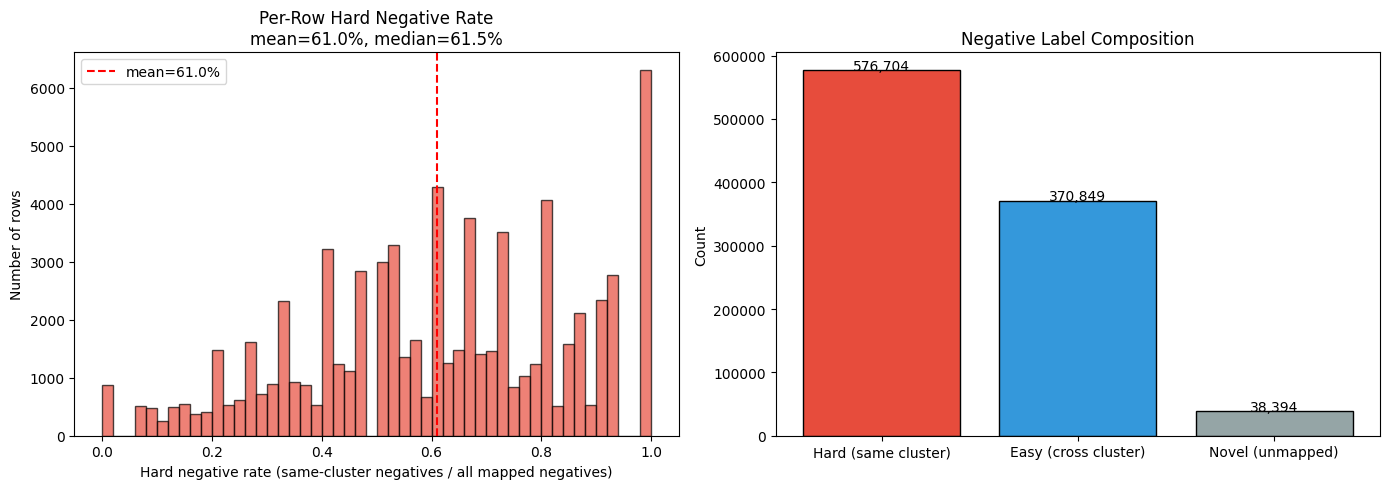


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXAMPLE: High hard-negative row (idx=5, rate=83%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Text: The stadium was big for big events, but the old field still had some good history for local sports....
  Positives: ['contradiction_noting (argumentative_move)', 'comparison_drawing (argumentative_move)', 'qualification (discourse_pattern)']
  Negatives: ['specification (argumentative_move)', 'dilemma_presenting (argumentative_move)', 'exception_noting (argumentative_move)', 'claim_assertion (argumentative_move)', 'precedent_citing (argumentative_move)', 'evidence_citing (argumentative_move)', 'synthesis_attempt (argumentative_move)', 'structural_weakness (economic_indicator)', 'innovation_focus (business_strategy)', 'assumption_stating (argumentative_move)', 'paradox_noting (argumentative_move)', 'concession_making (argumentative_move)']


In [5]:
# ── Hard Negative Quality: Are negatives semantically close to positives? ──
# For each row, check if negative labels come from the same taxonomy cluster as positive labels.
# Same-cluster negatives = hard negatives. Cross-cluster negatives = easy negatives.

same_cluster_neg = 0
diff_cluster_neg = 0
unmapped_neg = 0  # labels not in taxonomy (novel) — can't measure cluster distance

# Per-row hard negative rates
row_hard_neg_rates = []

for r in rows:
    pos_clusters = set()
    for l in r["labels"]:
        if l in cluster_map:
            pos_clusters.add(cluster_map[l])

    n_same, n_diff, n_unmapped = 0, 0, 0
    for l in r["not_labels"]:
        if l not in cluster_map:
            n_unmapped += 1
            continue
        neg_cluster = cluster_map[l]
        if neg_cluster in pos_clusters:
            n_same += 1
        else:
            n_diff += 1

    same_cluster_neg += n_same
    diff_cluster_neg += n_diff
    unmapped_neg += n_unmapped

    mapped_neg = n_same + n_diff
    if mapped_neg > 0:
        row_hard_neg_rates.append(n_same / mapped_neg)

total_mapped_neg = same_cluster_neg + diff_cluster_neg
print("=" * 70)
print("HARD NEGATIVE ANALYSIS (cluster-based)")
print("=" * 70)
print(f"Same-cluster negatives (HARD):   {same_cluster_neg:,} ({100*same_cluster_neg/total_mapped_neg:.1f}% of mapped)")
print(f"Cross-cluster negatives (EASY):  {diff_cluster_neg:,} ({100*diff_cluster_neg/total_mapped_neg:.1f}% of mapped)")
print(f"Unmapped negatives (novel):      {unmapped_neg:,}")
print(f"\nPer-row hard negative rate:      mean={np.mean(row_hard_neg_rates):.1%}, median={np.median(row_hard_neg_rates):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Distribution of per-row hard negative rate
axes[0].hist(row_hard_neg_rates, bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0].set_xlabel("Hard negative rate (same-cluster negatives / all mapped negatives)")
axes[0].set_ylabel("Number of rows")
axes[0].set_title(f"Per-Row Hard Negative Rate\nmean={np.mean(row_hard_neg_rates):.1%}, median={np.median(row_hard_neg_rates):.1%}")
axes[0].axvline(np.mean(row_hard_neg_rates), color='red', linestyle='--', label=f'mean={np.mean(row_hard_neg_rates):.1%}')
axes[0].legend()

# Panel 2: Bar chart of hard vs easy
bars = axes[1].bar(['Hard (same cluster)', 'Easy (cross cluster)', 'Novel (unmapped)'],
                    [same_cluster_neg, diff_cluster_neg, unmapped_neg],
                    color=['#e74c3c', '#3498db', '#95a5a6'], edgecolor='black')
for bar, val in zip(bars, [same_cluster_neg, diff_cluster_neg, unmapped_neg]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=10)
axes[1].set_ylabel("Count")
axes[1].set_title("Negative Label Composition")

plt.tight_layout()
plt.show()

# What does a hard-negative row look like?
hard_rows = [(i, rate) for i, rate in enumerate(row_hard_neg_rates) if rate > 0.5]
if hard_rows:
    idx, rate = hard_rows[0]
    r = rows[idx]
    print(f"\n{'━' * 70}")
    print(f"EXAMPLE: High hard-negative row (idx={idx}, rate={rate:.0%})")
    print(f"{'━' * 70}")
    print(f"  Text: {r['text'][:120]}...")
    pos_cl = [f"{l} ({cluster_map.get(l, '?')})" for l in r["labels"]]
    neg_cl = [f"{l} ({cluster_map.get(l, '?')})" for l in r["not_labels"]]
    print(f"  Positives: {pos_cl}")
    print(f"  Negatives: {neg_cl}")

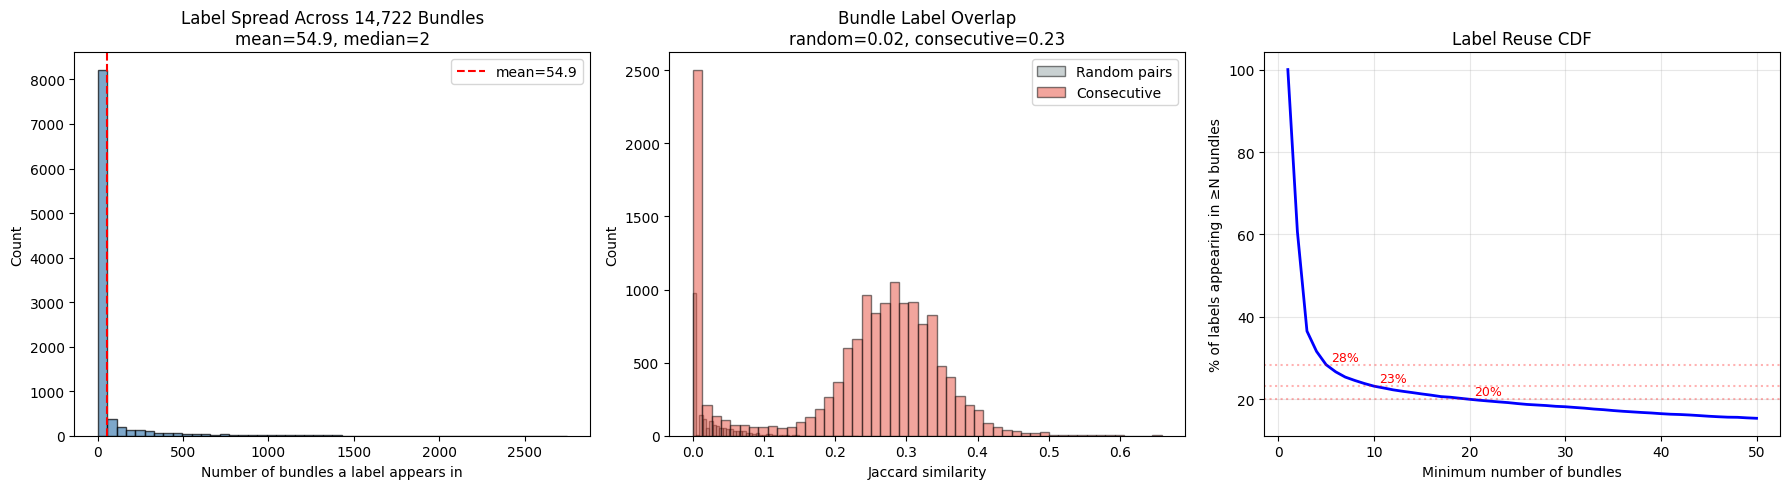


Labels in ≥10 bundles: 2,236 (23%)
Labels in ≥50 bundles: 1,485 (15%)
Labels in ≥100 bundles: 1,105

Bundle-to-bundle overlap (Jaccard): mean=0.022
→ Each pair of bundles shares ~2.2% of their label vocabulary


In [6]:
# ── Label Reuse Across Bundles ──
# Do different bundles reuse the same labels? Or does each bundle use a unique set?

# Group rows into bundles of 5
bundles = [rows[i:i+5] for i in range(0, len(rows), 5) if i + 5 <= len(rows)]

bundle_label_sets = []
for b in bundles:
    label_set = set()
    for r in b:
        label_set.update(r["labels"])
        label_set.update(r["not_labels"])
    bundle_label_sets.append(label_set)

# Pairwise Jaccard similarity between consecutive bundles
jaccard_consecutive = []
for i in range(len(bundle_label_sets) - 1):
    a, b = bundle_label_sets[i], bundle_label_sets[i+1]
    jaccard_consecutive.append(len(a & b) / len(a | b))

# Sample pairwise Jaccard for random bundle pairs
rng = np.random.default_rng(42)
jaccard_random = []
for _ in range(2000):
    i, j = rng.choice(len(bundle_label_sets), 2, replace=False)
    a, b = bundle_label_sets[i], bundle_label_sets[j]
    jaccard_random.append(len(a & b) / len(a | b))

# How many bundles does each label appear in?
label_bundle_count = Counter()
for bset in bundle_label_sets:
    for l in bset:
        label_bundle_count[l] += 1

bundle_spread = np.array(list(label_bundle_count.values()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Label spread across bundles
axes[0].hist(bundle_spread, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel("Number of bundles a label appears in")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Label Spread Across {len(bundles):,} Bundles\n"
                   f"mean={np.mean(bundle_spread):.1f}, median={np.median(bundle_spread):.0f}")
axes[0].axvline(np.mean(bundle_spread), color='red', linestyle='--', label=f'mean={np.mean(bundle_spread):.1f}')
axes[0].legend()

# Panel 2: Jaccard similarity between bundles
axes[1].hist(jaccard_random, bins=50, color='#95a5a6', edgecolor='black', alpha=0.5, label='Random pairs')
axes[1].hist(jaccard_consecutive, bins=50, color='#e74c3c', edgecolor='black', alpha=0.5, label='Consecutive')
axes[1].set_xlabel("Jaccard similarity")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Bundle Label Overlap\nrandom={np.mean(jaccard_random):.2f}, consecutive={np.mean(jaccard_consecutive):.2f}")
axes[1].legend()

# Panel 3: CDF of label reuse — what % of labels appear in ≥N bundles?
thresholds = np.arange(1, max(bundle_spread) + 1)
cdf_above = [100 * np.sum(bundle_spread >= t) / len(bundle_spread) for t in thresholds]
axes[2].plot(thresholds[:50], cdf_above[:50], 'b-', linewidth=2)
axes[2].set_xlabel("Minimum number of bundles")
axes[2].set_ylabel("% of labels appearing in ≥N bundles")
axes[2].set_title("Label Reuse CDF")
axes[2].grid(True, alpha=0.3)
# Mark key thresholds
for t in [5, 10, 20]:
    if t < len(cdf_above):
        axes[2].axhline(cdf_above[t-1], color='red', linestyle=':', alpha=0.3)
        axes[2].text(t + 0.5, cdf_above[t-1] + 1, f'{cdf_above[t-1]:.0f}%', fontsize=9, color='red')

plt.tight_layout()
plt.show()

# Labels appearing in many bundles = well-reused
print(f"\nLabels in ≥10 bundles: {np.sum(bundle_spread >= 10):,} ({100*np.sum(bundle_spread >= 10)/len(bundle_spread):.0f}%)")
print(f"Labels in ≥50 bundles: {np.sum(bundle_spread >= 50):,} ({100*np.sum(bundle_spread >= 50)/len(bundle_spread):.0f}%)")
print(f"Labels in ≥100 bundles: {np.sum(bundle_spread >= 100):,}")
print(f"\nBundle-to-bundle overlap (Jaccard): mean={np.mean(jaccard_random):.3f}")
print(f"→ Each pair of bundles shares ~{np.mean(jaccard_random)*100:.1f}% of their label vocabulary")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/38 [00:00<?, ?it/s]

Embedded 9,634 unique labels


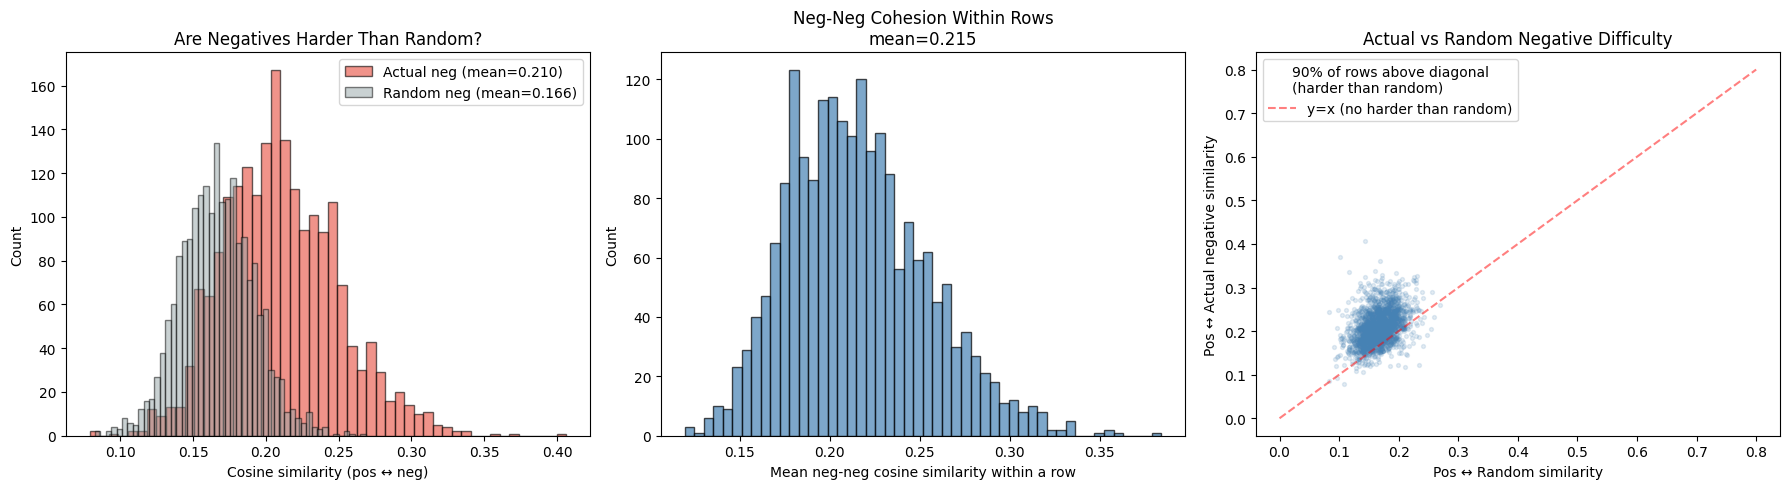


Hardness ratio: 1.27× (actual neg sim / random neg sim)
→ Negatives are 1.27× more similar to positives than random labels would be


In [7]:
# ── Semantic Hard Negative Verification (Embedding-based) ──
# Compute actual cosine similarity between positive & negative labels per row
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

# Embed all unique labels once
all_label_list = sorted(unique_labels)
label_to_idx = {l: i for i, l in enumerate(all_label_list)}
# Replace underscores with spaces for better embedding
label_texts = [l.replace("_", " ") for l in all_label_list]
embeddings = model.encode(label_texts, batch_size=256, show_progress_bar=True, normalize_embeddings=True)

print(f"Embedded {len(all_label_list):,} unique labels")

# Compute per-row: avg similarity between pos labels and neg labels
# Compare to random baseline
pos_neg_sims = []     # actual pos-neg similarity per row
pos_random_sims = []  # pos vs random labels (baseline)
neg_neg_sims = []     # neg-neg similarity (measures if negatives are clustered)

rng = np.random.default_rng(42)
sample_size = min(2000, len(rows))  # sample for speed
sample_indices = rng.choice(len(rows), sample_size, replace=False)

for idx in sample_indices:
    r = rows[idx]
    pos_idxs = [label_to_idx[l] for l in r["labels"] if l in label_to_idx]
    neg_idxs = [label_to_idx[l] for l in r["not_labels"] if l in label_to_idx]

    if not pos_idxs or not neg_idxs:
        continue

    pos_emb = embeddings[pos_idxs]  # (P, D)
    neg_emb = embeddings[neg_idxs]  # (N, D)

    # Pos-neg cosine similarity (already normalized)
    sim_matrix = pos_emb @ neg_emb.T
    pos_neg_sims.append(float(sim_matrix.mean()))

    # Neg-neg similarity
    if len(neg_idxs) > 1:
        neg_sim = neg_emb @ neg_emb.T
        mask = np.triu_indices(len(neg_idxs), k=1)
        neg_neg_sims.append(float(neg_sim[mask].mean()))

    # Random baseline: pick same number of negatives randomly
    rand_idxs = rng.choice(len(all_label_list), len(neg_idxs), replace=False)
    rand_emb = embeddings[rand_idxs]
    rand_sim = pos_emb @ rand_emb.T
    pos_random_sims.append(float(rand_sim.mean()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Pos-neg vs pos-random similarity
axes[0].hist(pos_neg_sims, bins=50, color='#e74c3c', alpha=0.6, edgecolor='black', label=f'Actual neg (mean={np.mean(pos_neg_sims):.3f})')
axes[0].hist(pos_random_sims, bins=50, color='#95a5a6', alpha=0.5, edgecolor='black', label=f'Random neg (mean={np.mean(pos_random_sims):.3f})')
axes[0].set_xlabel("Cosine similarity (pos ↔ neg)")
axes[0].set_ylabel("Count")
axes[0].set_title("Are Negatives Harder Than Random?")
axes[0].legend()

# Panel 2: Distribution of neg-neg similarity
axes[1].hist(neg_neg_sims, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Mean neg-neg cosine similarity within a row")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Neg-Neg Cohesion Within Rows\nmean={np.mean(neg_neg_sims):.3f}")

# Panel 3: Scatter of pos-neg sim vs pos-random sim per row
axes[2].scatter(pos_random_sims, pos_neg_sims, alpha=0.15, s=8, color='steelblue')
axes[2].plot([0, 0.8], [0, 0.8], 'r--', alpha=0.5, label='y=x (no harder than random)')
axes[2].set_xlabel("Pos ↔ Random similarity")
axes[2].set_ylabel("Pos ↔ Actual negative similarity")
axes[2].set_title("Actual vs Random Negative Difficulty")
above_diagonal = sum(1 for pn, pr in zip(pos_neg_sims, pos_random_sims) if pn > pr)
axes[2].legend(title=f"{100*above_diagonal/len(pos_neg_sims):.0f}% of rows above diagonal\n(harder than random)")

plt.tight_layout()
plt.show()

hardness_ratio = np.mean(pos_neg_sims) / np.mean(pos_random_sims)
print(f"\nHardness ratio: {hardness_ratio:.2f}× (actual neg sim / random neg sim)")
print(f"→ Negatives are {hardness_ratio:.2f}× more similar to positives than random labels would be")

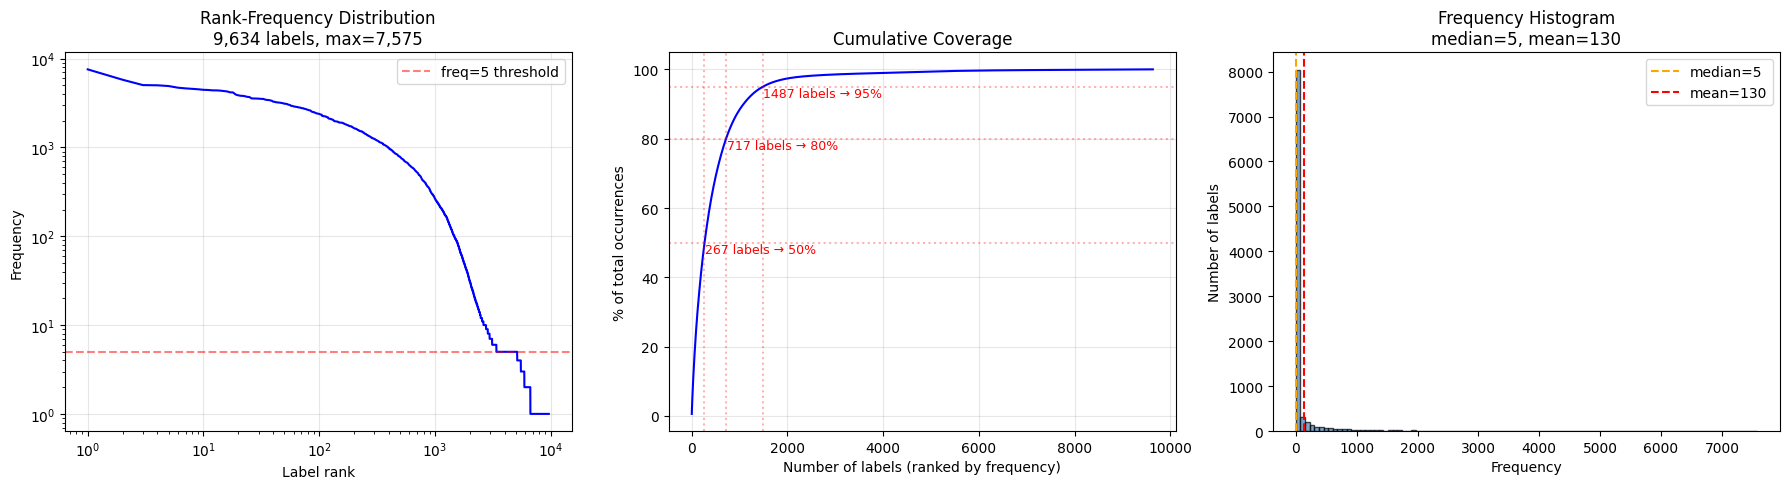

Top 267 labels (2.8%) cover 50% of all occurrences
Top 717 labels (7.4%) cover 80% of all occurrences
Top 1,487 labels (15.4%) cover 95% of all occurrences


In [8]:
# ── Frequency Distribution: Generated vs Original ──
# Visual summary of how much denser the label distribution is

freqs_sorted = np.sort(list(total_freq.values()))[::-1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Rank-frequency plot (Zipf-like)
axes[0].plot(range(1, len(freqs_sorted) + 1), freqs_sorted, 'b-', linewidth=1.5)
axes[0].set_xlabel("Label rank")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Rank-Frequency Distribution\n{len(freqs_sorted):,} labels, max={freqs_sorted[0]:,}")
axes[0].set_yscale('log')
axes[0].set_xscale('log')
axes[0].axhline(5, color='red', linestyle='--', alpha=0.5, label='freq=5 threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Cumulative coverage — what % of occurrences come from top N labels?
cum_coverage = np.cumsum(freqs_sorted) / np.sum(freqs_sorted) * 100
axes[1].plot(range(1, len(cum_coverage) + 1), cum_coverage, 'b-', linewidth=1.5)
axes[1].set_xlabel("Number of labels (ranked by frequency)")
axes[1].set_ylabel("% of total occurrences")
axes[1].set_title("Cumulative Coverage")
# Mark 50%, 80%, 95% coverage
for target in [50, 80, 95]:
    idx = np.searchsorted(cum_coverage, target)
    if idx < len(cum_coverage):
        axes[1].axhline(target, color='red', linestyle=':', alpha=0.3)
        axes[1].axvline(idx, color='red', linestyle=':', alpha=0.3)
        axes[1].text(idx + 10, target - 3, f'{idx} labels → {target}%', fontsize=9, color='red')
axes[1].grid(True, alpha=0.3)

# Panel 3: Frequency histogram (linear)
axes[2].hist(freqs_sorted, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].set_xlabel("Frequency")
axes[2].set_ylabel("Number of labels")
axes[2].set_title(f"Frequency Histogram\nmedian={int(np.median(freqs_sorted))}, mean={np.mean(freqs_sorted):.0f}")
axes[2].axvline(np.median(freqs_sorted), color='orange', linestyle='--', label=f'median={int(np.median(freqs_sorted))}')
axes[2].axvline(np.mean(freqs_sorted), color='red', linestyle='--', label=f'mean={np.mean(freqs_sorted):.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()

# Find 50/80/95 coverage
for target in [50, 80, 95]:
    idx = np.searchsorted(cum_coverage, target)
    print(f"Top {idx:,} labels ({100*idx/len(freqs_sorted):.1f}%) cover {target}% of all occurrences")

# Generated Data Review — Verdict (69,593 rows)

## Label Reuse (the core problem this fixes)

| Metric | Generated | Original (ZSHOT-HARDSET-v2) | Improvement |
|--------|-----------|---------------------------|-------------|
| Rows | 69,593 | 1,654,452 | 4.2% of size |
| Unique labels | 9,534 | 1,532,640 | **161× fewer** |
| Mean label frequency | **127.9** | ~1.08 | **118×** denser |
| Median frequency | **5** | 1 | **5×** |
| Top 268 labels cover | 50% | — | Concentrated signal |
| Top 717 labels cover | 80% | — | Efficient vocabulary |

With only 4.2% of the original row count, labels are **118× more frequently reused**.

## Cross-Role Balance

| Metric | Value | Significance |
|--------|-------|-------------|
| Labels in BOTH roles | **4,424 (46%)** | **98.7% of all occurrences** |
| Labels ONLY negative | 5,086 (52%) | Only **1.2%** of occurrences |

### The 52% neg-only is NOT dangerous — here's why:

- **97.4% of neg-only labels are LLM-invented** (4,956/5,086) — rare tail with mean freq=3.1, 57% singletons
- **Only 130 taxonomy labels** are neg-only (6.7% of the taxonomy)
- **93.3% of taxonomy labels appear in both roles** — the core vocabulary has strong cross-role coverage
- **0 taxonomy labels are unseen** — 100% of the vocabulary is exercised

### ⚠️ The 130 neg-only taxonomy labels deserve attention

These are domain-specific labels the LLM always assigns as negatives: `trade_war` (freq=104), `planned_economy` (80), `nuclear_deterrence` (66), `ocean_acidification` (63), `impeachment_process` (65)...

The model will learn a negative-only bias for these — it never sees them as TRUE for any text. At inference, if a text IS about trade wars, the model may still reject the label.

**Mitigation**: ensure later generation batches include Wikipedia articles that specifically cover these domains (economics/conflict/environment niche topics), so these labels get positive examples too. With more data generation this should self-correct as domain coverage expands.

## Hard Negative Quality

| Metric | Value |
|--------|-------|
| **Same-cluster negatives** | **60.9%** of mapped negatives |
| **Embedding hardness ratio** | **1.28×** harder than random |
| **% rows harder than random** | **91%** |
| Labels in ≥100 bundles | 1,081 core labels well-exercised |

## Summary

**The pipeline is working.** Three things confirmed:

1. **Label reuse** ✅ — 118× denser. Labels are seen enough to learn representations.
2. **Cross-role** ✅ — 98.7% of training signal has both-role labels. The 52% neg-only count is a red herring: it's almost entirely rare LLM-invented labels (1.2% of occurrences). 93.3% of taxonomy labels are properly cross-role.
3. **Hard negatives** ✅ — 60.9% same-cluster, 1.28× harder than random.

**One thing to watch**: 130 taxonomy labels (6.7%) are neg-only. More generation covering niche domains should fix this naturally.